# **Import Libraries**

In [1]:
from google.colab import drive
drive.mount('/content/drive')
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.cluster import KMeans
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score, KFold
from scipy.stats import shapiro, f_oneway, stats
from statsmodels.stats.multicomp import MultiComparison
from yellowbrick.regressor import ResidualsPlot

Mounted at /content/drive


# **Regression algorithms for farm areas**



In [2]:
# Load data
all_areas_df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/files/data_integration_all_areas.csv")

In [3]:
all_areas_df.select_dtypes(include=['int64','float64'])

,index,farm,area_cod,area_size,CO_emission_ha,CO_emission_area,CO_stock_ha,CO_stock_area,balance_CO2_area,balance_CO2_ha,city_cod,state_cod,biome_cod,climate_cod,year
0,1,4575772,15,4.44,8.6000,38.184000,37.996991,168.706641,130.522641,29.396991,1100015,11,1,2,2021
1,2,4564180,15,1.74,8.6000,14.964000,37.996991,66.114765,51.150765,29.396991,1100015,11,1,2,2021
2,3,4572695,3,1.02,0.0000,0.000000,41.235859,42.060576,42.060576,41.235859,1100015,11,1,2,2021
3,4,4572695,15,8.23,8.6000,70.778000,37.996991,312.715238,241.937238,29.396991,1100015,11,1,2,2021
4,5,4574104,15,2.51,8.6000,21.586000,37.996991,95.372448,73.786448,29.396991,1100015,11,1,2,2021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295849,295850,4481025,12,0.36,0.2800,0.100800,37.826270,13.617457,13.516657,37.546270,5107602,51,6,4,2021
295850,295851,4481025,15,1993.95,0.2800,558.306000,33.807848,67411.159059,66852.853059,33.527848,5107602,51,6,4,2021
295851,295852,4481025,21,233.97,0.2800,65.511600,36.202534,8470.306846,8404.795246,35.922534,5107602,51,6,4,2021
295852,295853,4481025,39,1551.05,0.3200,496.336000,48.400323,75071.320385,74574.984385,48.080323,5107602,51,6,4,2021


<Axes: >

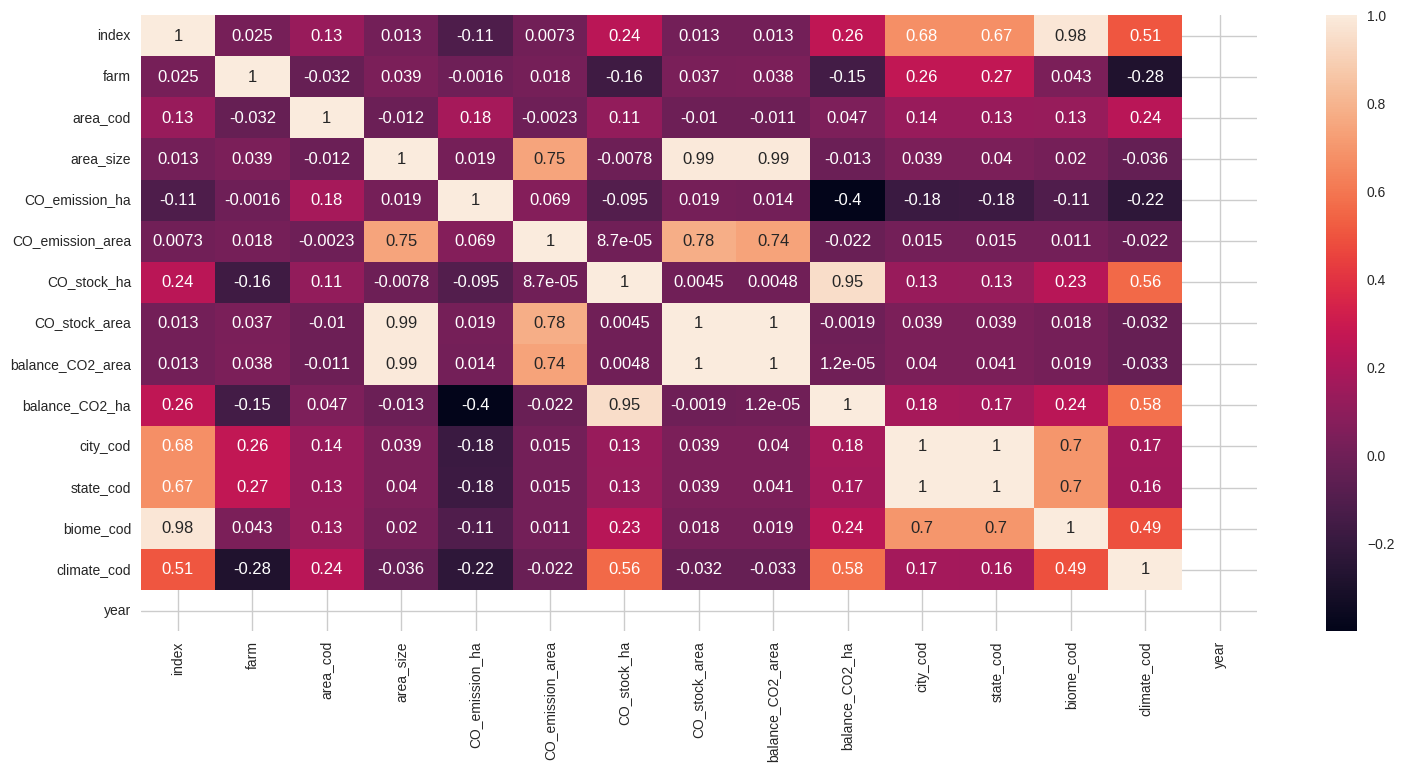

In [4]:
# Correlation
all_areas_df_corr = all_areas_df.select_dtypes(include=['int64','float64'])
figura = plt.figure(figsize=(18,8))
sns.heatmap(all_areas_df_corr.corr(), annot=True)

In [5]:
all_areas_df.count()

,0
index,295854
farm,295854
area_cod,295854
area_name,295854
area_size,295854
CO_emission_ha,295854
CO_emission_area,295854
CO_stock_ha,295854
CO_stock_area,295854
balance_CO2_area,295854


#**Linear Regression - Simple**

In [6]:
# X is the attribute: area_cod (predictor attribute) => (area_cod: 2, climate_cod: 17)
X_areas = all_areas_df.iloc[:, 17].values
X_areas

array([2, 2, 2, ..., 4, 4, 4])

In [7]:
# Y is the attribute: balance_CO2_ha
Y_areas = all_areas_df.iloc[:, 10].values
Y_areas

array([29.39699123, 29.39699123, 41.23585922, ..., 35.92253386,
       48.08032261, 35.17022823])

In [8]:
X_areas.shape, Y_areas.shape

((295854,), (295854,))

In [9]:
# Correlation coefficient
np.corrcoef(X_areas, Y_areas)

array([[1.        , 0.58368123],
       [0.58368123, 1.        ]])

In [10]:
# Transforming array into matrix (required for sklearn)
X_areas = X_areas.reshape(-1,1)
X_areas

array([[2],
       [2],
       [2],
       ...,
       [4],
       [4],
       [4]])

In [11]:
X_areas.shape

(295854, 1)

**Standardization, if necessary**

In [12]:
scaler_areas_x = StandardScaler()
X_areas = scaler_areas_x.fit_transform((X_areas).reshape(-1,1))
scaler_areas_y = StandardScaler()
Y_areas = scaler_areas_y.fit_transform((Y_areas).reshape(-1,1))
X_areas, Y_areas

(array([[-1.20113363],
        [-1.20113363],
        [-1.20113363],
        ...,
        [-0.27637271],
        [-0.27637271],
        [-0.27637271]]),
 array([[-1.36183764],
        [-1.36183764],
        [-0.03521227],
        ...,
        [-0.63060637],
        [ 0.73175623],
        [-0.71490732]]))

**Using the entire database**

In [13]:
# Create the regression model (for all data)
simple_linear_regressor = LinearRegression()
simple_linear_regressor.fit(X_areas, Y_areas)

LinearRegression()

In [14]:
# b0 : beginning of the regression line and b1: slope of the line
simple_linear_regressor.intercept_, simple_linear_regressor.coef_

(array([1.90435719e-15]), array([[0.58368123]]))

In [15]:
# Prevision
prevision_simple_linear_regressor = simple_linear_regressor.predict(X_areas)
prevision_simple_linear_regressor

array([[-0.70107916],
       [-0.70107916],
       [-0.70107916],
       ...,
       [-0.16131357],
       [-0.16131357],
       [-0.16131357]])

In [16]:
# Convert matrix to array (for the graph)
X_areas.ravel()

array([-1.20113363, -1.20113363, -1.20113363, ..., -0.27637271,
       -0.27637271, -0.27637271])

In [17]:
# Prediction with a value  (area 15) = estimated value of carbon/ha
simple_linear_regressor.intercept_ + simple_linear_regressor.coef_ * 15

array([[8.75521849]])

In [18]:
# OR using matrix format
simple_linear_regressor.predict([[15]])

array([[8.75521849]])

In [19]:
# score: algorithm quality metric (closest to 1 best value)
simple_linear_regressor.score(X_areas, Y_areas)

0.34068378164485313

In [20]:
# Mean absolute error
mean_absolute_error(Y_areas, prevision_simple_linear_regressor)

0.6199807079043039

In [21]:
# Mean squared error
mean_squared_error(Y_areas, prevision_simple_linear_regressor)

0.6593162183551468

In [22]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas, prevision_simple_linear_regressor))

np.float64(0.8119828928956242)

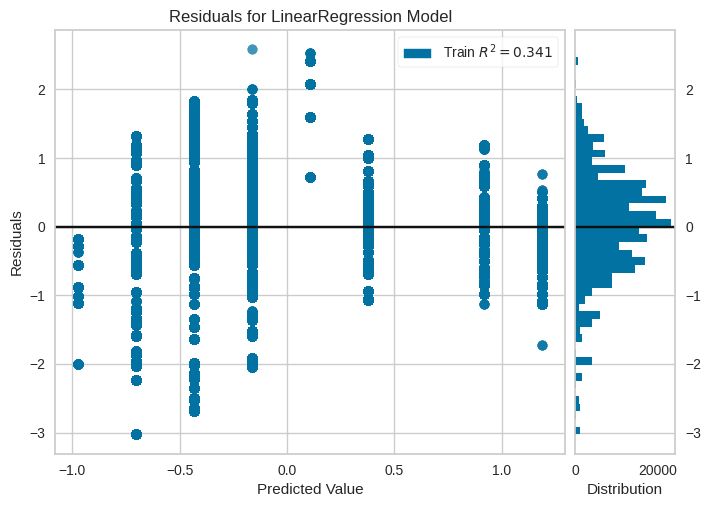

<Axes: title={'center': 'Residuals for LinearRegression Model'}, xlabel='Predicted Value', ylabel='Residuals'>

In [23]:
# distance from the original values to the linear regression line (Train R2 = algorithm quality)
viewer = ResidualsPlot(simple_linear_regressor)
viewer.fit(X_areas, Y_areas)
viewer.poof()

<Axes: >

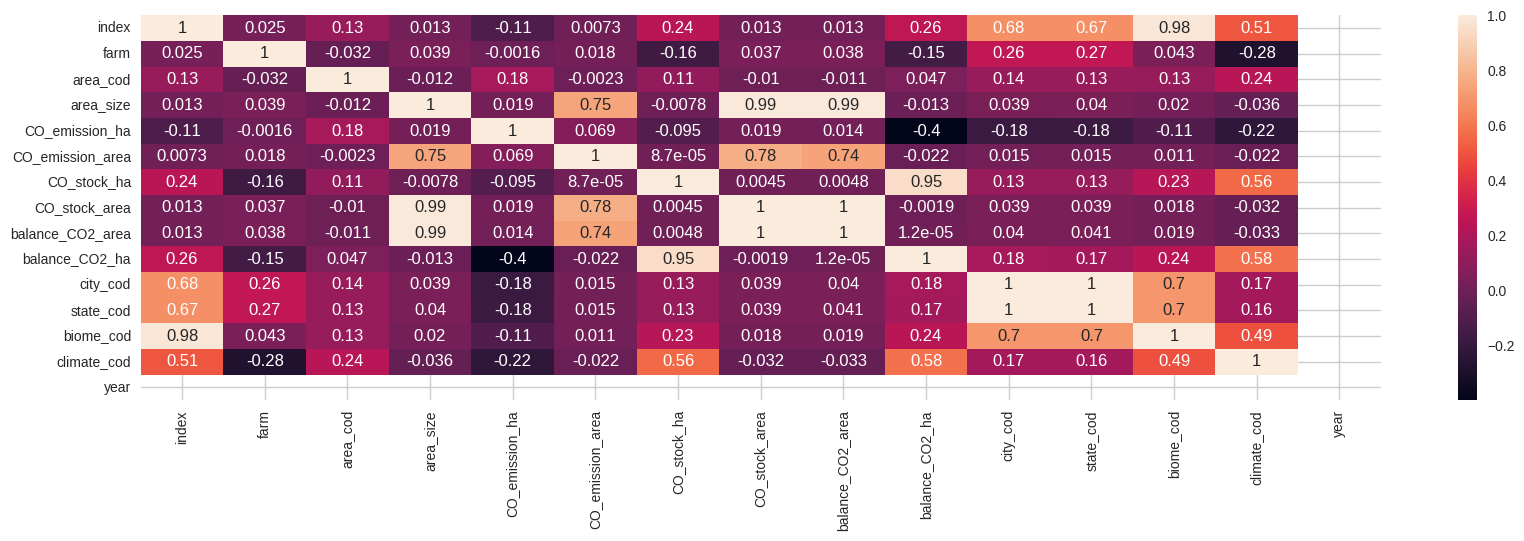

In [24]:
# Correlation viewer
figure = plt.figure(figsize=(20,5))
sns.heatmap(all_areas_df_corr.corr(), annot=True)

**Simple Linear Regression - training and testing bases**

In [25]:
# Division of bases (75% trein, 25% test)
X_areas_trein, X_areas_test, Y_areas_trein, Y_areas_test = train_test_split(X_areas, Y_areas, test_size = 0.25, random_state = 0)

In [26]:
X_areas_trein.shape, Y_areas_trein.shape, X_areas_test.shape, Y_areas_test.shape

((221890, 1), (221890, 1), (73964, 1), (73964, 1))


**Standardization, if necessary**

In [27]:
scaler_areas_x = StandardScaler()
X_areas_trein = scaler_areas_x.fit_transform((X_areas_trein).reshape(-1,1))
X_areas_test = scaler_areas_x.fit_transform((X_areas_test).reshape(-1,1))

scaler_areas_y = StandardScaler()
Y_areas_trein = scaler_areas_y.fit_transform((Y_areas_trein).reshape(-1,1))
Y_areas_test = scaler_areas_y.fit_transform((Y_areas_test).reshape(-1,1))

X_areas_trein, Y_areas_trein, X_areas_test, Y_areas_test


(array([[ 2.03518839],
        [ 0.64786545],
        [-0.27701651],
        ...,
        [-0.27701651],
        [ 1.57274741],
        [-0.27701651]]),
 array([[1.37988252],
        [0.09106802],
        [1.19865699],
        ...,
        [0.2936487 ],
        [0.87511653],
        [0.72593471]]),
 array([[ 0.64995711],
        [-0.274443  ],
        [ 2.03655729],
        ...,
        [-0.274443  ],
        [ 1.57435723],
        [-0.274443  ]]),
 array([[0.09316035],
        [0.14404696],
        [1.36145186],
        ...,
        [1.3654358 ],
        [0.88713245],
        [0.80859292]]))

**Regression Model for training**

In [28]:
# Convert array to matrix
X_areas_trein = X_areas_trein.reshape(-1,1)
X_areas_trein

array([[ 2.03518839],
       [ 0.64786545],
       [-0.27701651],
       ...,
       [-0.27701651],
       [ 1.57274741],
       [-0.27701651]])

In [29]:
# Create the regression model (trein)
simple_linear_regressor_trein = LinearRegression()
simple_linear_regressor_trein.fit(X_areas_trein, Y_areas_trein)

LinearRegression()

In [30]:
# score: algorithm quality metric (trein)
simple_linear_regressor_trein.score(X_areas_trein, Y_areas_trein)

0.3417059395632749

In [31]:
# Prevision (trein)
prevision_simple_linear_regressor_trein = simple_linear_regressor_trein.predict(X_areas_trein)
prevision_simple_linear_regressor_trein

array([[ 1.18968197],
       [ 0.37871376],
       [-0.16193171],
       ...,
       [-0.16193171],
       [ 0.91935924],
       [-0.16193171]])

In [32]:
# Real data
Y_areas_trein

array([[1.37988252],
       [0.09106802],
       [1.19865699],
       ...,
       [0.2936487 ],
       [0.87511653],
       [0.72593471]])

In [33]:
# Mean absolute error
abs(Y_areas_trein-prevision_simple_linear_regressor_trein).mean()

np.float64(0.619541169767389)

In [34]:
# Mean absolute error
mean_absolute_error(Y_areas_trein, prevision_simple_linear_regressor_trein)

0.619541169767389

In [35]:
# Mean squared error
mean_squared_error(Y_areas_trein, prevision_simple_linear_regressor_trein)

0.6582940604367249

In [36]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_trein, prevision_simple_linear_regressor_trein))

np.float64(0.8113532279079962)

In [37]:
# Prediction with a value  (area 15) = estimated value of carbon/ha
simple_linear_regressor_trein.intercept_ + simple_linear_regressor_trein.coef_ * 15

array([[8.76834285]])

**Regression Model for testing**

In [38]:
# Convert array to matrix
X_areas_test = X_areas_test.reshape(-1,1)
X_areas_test

array([[ 0.64995711],
       [-0.274443  ],
       [ 2.03655729],
       ...,
       [-0.274443  ],
       [ 1.57435723],
       [-0.274443  ]])

In [39]:
# Create the regression model (test)
simple_linear_regressor_test = LinearRegression()
simple_linear_regressor_test.fit(X_areas_test, Y_areas_test)

LinearRegression()

In [40]:
# score: algorithm quality metric (test)
simple_linear_regressor_test.score(X_areas_test, Y_areas_test)

0.33763636958827004

In [41]:
# Prevision (test)
prevision_simple_linear_regressor_test = simple_linear_regressor_test.predict(X_areas_test)
prevision_simple_linear_regressor_test

array([[ 0.37766724],
       [-0.15946918],
       [ 1.18337187],
       ...,
       [-0.15946918],
       [ 0.91480366],
       [-0.15946918]])

In [42]:
# Real data
Y_areas_test

array([[0.09316035],
       [0.14404696],
       [1.36145186],
       ...,
       [1.3654358 ],
       [0.88713245],
       [0.80859292]])

In [43]:
# Mean absolute error
abs(Y_areas_test-prevision_simple_linear_regressor_test).mean()

np.float64(0.6212967986959026)

In [44]:
# Mean absolute error
mean_absolute_error(Y_areas_test, prevision_simple_linear_regressor_test)

0.6212967986959026

In [45]:
# Mean squared error
mean_squared_error(Y_areas_test, prevision_simple_linear_regressor_test)

0.6623636304117302

In [46]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_test, prevision_simple_linear_regressor_test))

np.float64(0.8138572543214997)

In [47]:
# Prediction with a value  (area 15) = estimated value of carbon/ha
simple_linear_regressor_trein.intercept_ + simple_linear_regressor_trein.coef_ * 15

array([[8.76834285]])

# **Linear Regression - Multiple**

In [48]:
# X composed of attributes: area_cod, city_cod, climate_cod
X_areas_mult = all_areas_df.iloc[:, [2,11,17]].values
X_areas_mult

array([[     15, 1100015,       2],
       [     15, 1100015,       2],
       [      3, 1100015,       2],
       ...,
       [     21, 5107602,       4],
       [     39, 5107602,       4],
       [     41, 5107602,       4]])

In [49]:
# # Y is the attribute: balance_CO2_ha
Y_areas_mult = all_areas_df.iloc[:, 10].values
Y_areas_mult

array([29.39699123, 29.39699123, 41.23585922, ..., 35.92253386,
       48.08032261, 35.17022823])

**Using the entire database**

**Standardization, if necessary**

In [50]:
scaler_areas_x = StandardScaler()
X_areas_mult = scaler_areas_x.fit_transform((X_areas_mult))
scaler_areas_y = StandardScaler()
Y_areas_mult = scaler_areas_y.fit_transform((Y_areas_mult).reshape(-1,1))
X_areas_mult, Y_areas_mult

(array([[-0.0344385 , -1.83221148, -1.20113363],
        [-0.0344385 , -1.83221148, -1.20113363],
        [-1.00428164, -1.83221148, -1.20113363],
        ...,
        [ 0.45048307,  0.99010701, -0.27637271],
        [ 1.90524778,  0.99010701, -0.27637271],
        [ 2.06688831,  0.99010701, -0.27637271]]),
 array([[-1.36183764],
        [-1.36183764],
        [-0.03521227],
        ...,
        [-0.63060637],
        [ 0.73175623],
        [-0.71490732]]))

In [51]:
# Create the regression model (for all data)
mult_linear_regressor = LinearRegression()
mult_linear_regressor.fit(X_areas_mult, Y_areas_mult)

LinearRegression()

In [52]:
# Prevision
prevision_mult_linear_regressor = mult_linear_regressor.predict(X_areas_mult)
prevision_mult_linear_regressor

array([[-0.87440906],
       [-0.87440906],
       [-0.77220399],
       ...,
       [-0.12184585],
       [-0.27515346],
       [-0.29218764]])

In [53]:
# score: algorithm quality metric (closest to 1 best value)
mult_linear_regressor.score(X_areas_mult, Y_areas_mult)

0.3572938951334522

In [54]:
# Mean absolute error
mean_absolute_error(Y_areas_mult, prevision_mult_linear_regressor)

0.6027029790874777

In [55]:
# Mean squared error
mean_squared_error(Y_areas_mult, prevision_mult_linear_regressor)

0.6427061048665477

In [56]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_mult, prevision_mult_linear_regressor))

np.float64(0.8016895314687275)

**Multiple Linear Regression - training and testing bases**

In [57]:
# Division of bases (75% trein, 25% test)
X_areas_mult_trein, X_areas_mult_test, Y_areas_mult_trein, Y_areas_mult_test = train_test_split(X_areas_mult, Y_areas_mult, test_size = 0.25, random_state = 0)

In [58]:
X_areas_mult_trein.shape, Y_areas_mult_trein.shape, X_areas_mult_test.shape, Y_areas_mult_test.shape

((221890, 3), (221890, 1), (73964, 3), (73964, 1))

**Standardization, if necessary**


In [59]:
scaler_areas_x_mult = StandardScaler()
X_areas_mult_trein = scaler_areas_x_mult.fit_transform((X_areas_mult_trein))
X_areas_mult_test = scaler_areas_x_mult.fit_transform((X_areas_mult_test))

scaler_areas_y_mult = StandardScaler()
Y_areas_mult_trein = scaler_areas_y_mult.fit_transform((Y_areas_mult_trein))
Y_areas_mult_test = scaler_areas_y_mult.fit_transform((Y_areas_mult_test))

X_areas_mult_trein, Y_areas_mult_trein, X_areas_mult_test, Y_areas_mult_test

(array([[ 0.45264221, -0.40817253,  2.03518839],
        [-0.27572353,  0.43195891,  0.64786545],
        [ 1.90937368,  1.06239137, -0.27701651],
        ...,
        [-0.27572353,  1.05710842, -0.27701651],
        [-1.00408927, -0.42303168,  1.57274741],
        [-0.92315974,  1.05710842, -0.27701651]]),
 array([[1.37988252],
        [0.09106802],
        [1.19865699],
        ...,
        [0.2936487 ],
        [0.87511653],
        [0.72593471]]),
 array([[-0.28041459,  0.43718486,  0.64995711],
        [ 0.36355546,  1.06227289, -0.274443  ],
        [-0.03892582, -0.40224914,  2.03655729],
        ...,
        [ 1.89298431,  1.06181542, -0.274443  ],
        [-1.00488089, -0.40175436,  1.57435723],
        [-0.92438464,  0.99009391, -0.274443  ]]),
 array([[0.09316035],
        [0.14404696],
        [1.36145186],
        ...,
        [1.3654358 ],
        [0.88713245],
        [0.80859292]]))

**Regression Model for training**

In [60]:
# Create the regression model (trein)
mult_linear_regressor_trein = LinearRegression()
mult_linear_regressor_trein.fit(X_areas_mult_trein, Y_areas_mult_trein)

LinearRegression()

In [61]:
# score: algorithm quality metric (trein)
mult_linear_regressor_trein.score(X_areas_mult_trein, Y_areas_mult_trein)

0.3582179463256123

In [62]:
# Prevision (trein)
prevision_mult_linear_regressor_trein = mult_linear_regressor_trein.predict(X_areas_mult_trein)
prevision_mult_linear_regressor_trein

array([[ 1.12410998],
       [ 0.45264432],
       [-0.26770487],
       ...,
       [-0.03984393],
       [ 1.00041134],
       [ 0.02781231]])

In [63]:
# Real data
Y_areas_mult_trein

array([[1.37988252],
       [0.09106802],
       [1.19865699],
       ...,
       [0.2936487 ],
       [0.87511653],
       [0.72593471]])

In [64]:
# Mean absolute error
mean_absolute_error(Y_areas_mult_trein, prevision_mult_linear_regressor_trein)

0.6022214448090426

In [65]:
# Mean squared error
mean_squared_error(Y_areas_mult_trein, prevision_mult_linear_regressor_trein)

0.6417820536743875

In [66]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_mult_trein, prevision_mult_linear_regressor_trein))

np.float64(0.8011130093029244)

**Regression Model for testing**

In [67]:
# Create the regression model (test)
mult_linear_regressor_test = LinearRegression()
mult_linear_regressor_test.fit(X_areas_mult_test, Y_areas_mult_test)

LinearRegression()

In [68]:
# score: algorithm quality metric (test)
mult_linear_regressor_test.score(X_areas_mult_test, Y_areas_mult_test)

0.3545470908591849

In [69]:
# Prevision (test)
prevision_mult_linear_regressor_test = mult_linear_regressor_test.predict(X_areas_mult_test)
prevision_mult_linear_regressor_test

array([[ 0.45366672],
       [-0.10607552],
       [ 1.17168035],
       ...,
       [-0.27131204],
       [ 1.00290063],
       [ 0.02655509]])

In [70]:
# Real data
Y_areas_mult_test

array([[0.09316035],
       [0.14404696],
       [1.36145186],
       ...,
       [1.3654358 ],
       [0.88713245],
       [0.80859292]])

In [71]:
# Mean absolute error
mean_absolute_error(Y_areas_mult_test, prevision_mult_linear_regressor_test)

0.6041371622746206

In [72]:
# Mean squared error
mean_squared_error(Y_areas_mult_test, prevision_mult_linear_regressor_test)

0.6454529091408153

In [73]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_mult_test, prevision_mult_linear_regressor_test))

np.float64(0.8034008396440816)

# **Polynomial Regression**

In [74]:
# X is the attribute: area_cod (predictor attribute) => (area_cod: 2, climate_cod: 17)
X_areas = all_areas_df.iloc[:, 17].values
X_areas

array([2, 2, 2, ..., 4, 4, 4])

In [75]:
# Y is the attribute: balance_CO2_ha
Y_areas = all_areas_df.iloc[:, 10].values
Y_areas

array([29.39699123, 29.39699123, 41.23585922, ..., 35.92253386,
       48.08032261, 35.17022823])

In [76]:
scaler_polynomial_x = StandardScaler()
X_areas  = scaler_polynomial_x.fit_transform(X_areas.reshape(-1,1))
X_areas

array([[-1.20113363],
       [-1.20113363],
       [-1.20113363],
       ...,
       [-0.27637271],
       [-0.27637271],
       [-0.27637271]])

In [77]:
scaler_polynomial_y = StandardScaler()
Y_areas  = scaler_polynomial_y.fit_transform(Y_areas.reshape(-1,1))
Y_areas

array([[-1.36183764],
       [-1.36183764],
       [-0.03521227],
       ...,
       [-0.63060637],
       [ 0.73175623],
       [-0.71490732]])

In [78]:
# Apply degree to the polynomial
polynomial_degree = PolynomialFeatures(degree=8)

**Using the entire database**

In [79]:
# Transforming array into matrix (required for sklearn)
X_areas = X_areas.reshape(-1,1)
X_areas

array([[-1.20113363],
       [-1.20113363],
       [-1.20113363],
       ...,
       [-0.27637271],
       [-0.27637271],
       [-0.27637271]])

In [80]:
# Apply polynominal degree in X
X_areas_poly = polynomial_degree.fit_transform(X_areas)

In [81]:
X_areas_poly.shape

(295854, 9)

In [82]:
X_areas_poly

array([[ 1.00000000e+00, -1.20113363e+00,  1.44272200e+00, ...,
         3.00294903e+00, -3.60694307e+00,  4.33242062e+00],
       [ 1.00000000e+00, -1.20113363e+00,  1.44272200e+00, ...,
         3.00294903e+00, -3.60694307e+00,  4.33242062e+00],
       [ 1.00000000e+00, -1.20113363e+00,  1.44272200e+00, ...,
         3.00294903e+00, -3.60694307e+00,  4.33242062e+00],
       ...,
       [ 1.00000000e+00, -2.76372714e-01,  7.63818772e-02, ...,
         4.45626473e-04, -1.23158998e-04,  3.40377866e-05],
       [ 1.00000000e+00, -2.76372714e-01,  7.63818772e-02, ...,
         4.45626473e-04, -1.23158998e-04,  3.40377866e-05],
       [ 1.00000000e+00, -2.76372714e-01,  7.63818772e-02, ...,
         4.45626473e-04, -1.23158998e-04,  3.40377866e-05]])

In [83]:
# Create the regression model (for all data)
poly_simple_linear_regressor = LinearRegression()
poly_simple_linear_regressor.fit(X_areas_poly, Y_areas)

LinearRegression()

In [84]:
# Score: algorithm quality metric (closest to 1 best value)
poly_simple_linear_regressor.score(X_areas_poly, Y_areas)

0.3918856233411465

In [85]:
# Prevision
prevision_poly_simple_linear_regressor = poly_simple_linear_regressor.predict(X_areas_poly)
prevision_poly_simple_linear_regressor

array([[-0.62973082],
       [-0.62973082],
       [-0.62973082],
       ...,
       [-0.07836126],
       [-0.07836126],
       [-0.07836126]])

In [86]:
# Real data
Y_areas

array([[-1.36183764],
       [-1.36183764],
       [-0.03521227],
       ...,
       [-0.63060637],
       [ 0.73175623],
       [-0.71490732]])

In [87]:
# Mean absolute error
mean_absolute_error(Y_areas, prevision_poly_simple_linear_regressor)

0.5810945131093879

In [88]:
# Mean squared error
mean_squared_error(Y_areas, prevision_poly_simple_linear_regressor)

0.6081143766588534

In [89]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas, prevision_poly_simple_linear_regressor))

np.float64(0.7798168866207331)

In [90]:
# Prevision
new_value = [[15]]
new_value = polynomial_degree.transform(new_value)
new_value

array([[1.00000000e+00, 1.50000000e+01, 2.25000000e+02, 3.37500000e+03,
        5.06250000e+04, 7.59375000e+05, 1.13906250e+07, 1.70859375e+08,
        2.56289062e+09]])

In [91]:
poly_simple_linear_regressor.predict(new_value)

array([[3.28137812e+08]])

**Polynomial Linear Regression - training and testing bases**

In [92]:
# Division of bases (75% trein, 25% test)
X_areas_trein, X_areas_test, Y_areas_trein, Y_areas_test = train_test_split(X_areas, Y_areas, test_size = 0.25, random_state = 0)

**Regression Model for training**

In [93]:
X_areas_trein.shape, Y_areas_trein.shape

((221890, 1), (221890, 1))

In [94]:
# Transforming array into matrix (required for sklearn)
X_areas_trein = X_areas_trein.reshape(-1,1)
X_areas_trein

array([[ 2.03552957],
       [ 0.6483882 ],
       [-0.27637271],
       ...,
       [-0.27637271],
       [ 1.57314912],
       [-0.27637271]])

In [95]:
# Apply polynominal degree in X
X_areas_trein_poly = polynomial_degree.fit_transform(X_areas_trein)
X_areas_trein_poly.shape

(221890, 9)

In [96]:
# Create the regression model
poly_simple_linear_regressor_trein = LinearRegression()
poly_simple_linear_regressor_trein.fit(X_areas_trein_poly, Y_areas_trein)

LinearRegression()

In [97]:
# Score: algorithm quality metric (closest to 1 best value)
poly_simple_linear_regressor_trein.score(X_areas_trein_poly, Y_areas_trein)

0.3926427816324488

In [98]:
# Prevision
prevision_poly_simple_linear_regressor_trein = poly_simple_linear_regressor_trein.predict(X_areas_trein_poly)
prevision_poly_simple_linear_regressor_trein

array([[ 1.52793502],
       [ 0.18506733],
       [-0.07809472],
       ...,
       [-0.07809472],
       [ 0.67279407],
       [-0.07809472]])

In [99]:
# Real data
Y_areas_trein

array([[1.37946467],
       [0.09159213],
       [1.1983716 ],
       ...,
       [0.29402475],
       [0.8750676 ],
       [0.72599482]])

In [100]:
# Mean absolute error
mean_absolute_error(Y_areas_trein, prevision_poly_simple_linear_regressor_trein)

0.5804151218731954

In [101]:
# Mean squared error
mean_squared_error(Y_areas_trein, prevision_poly_simple_linear_regressor_trein)

0.6064697409066548

In [102]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_trein, prevision_poly_simple_linear_regressor_trein))

np.float64(0.7787616714416901)

**Regression Model for testing**

In [103]:
X_areas_test.shape, Y_areas_test.shape

((73964, 1), (73964, 1))

In [104]:
# Transforming array into matrix (required for sklearn)
X_areas_test = X_areas_test.reshape(-1,1)
X_areas_test

array([[ 0.6483882 ],
       [-0.27637271],
       [ 2.03552957],
       ...,
       [-0.27637271],
       [ 1.57314912],
       [-0.27637271]])

In [105]:
# Apply polynominal degree in X
X_areas_test_poly = polynomial_degree.fit_transform(X_areas_test)
X_areas_test_poly.shape

(73964, 9)

In [106]:
# Create the regression model
poly_simple_linear_regressor_test = LinearRegression()
poly_simple_linear_regressor_test.fit(X_areas_test_poly, Y_areas_test)

LinearRegression()

In [107]:
# Score: algorithm quality metric (closest to 1 best value)
poly_simple_linear_regressor_test.score(X_areas_test_poly, Y_areas_test)

0.38964622596104725

In [108]:
# Prevision
prevision_poly_simple_linear_regressor_test = poly_simple_linear_regressor_test.predict(X_areas_test_poly)
prevision_poly_simple_linear_regressor_test

array([[ 0.17914712],
       [-0.07916394],
       [ 1.53071471],
       ...,
       [-0.07916394],
       [ 0.66618879],
       [-0.07916394]])

In [109]:
# Real data
Y_areas_test

array([[0.09159213],
       [0.14259004],
       [1.36265778],
       ...,
       [1.36665044],
       [0.8873009 ],
       [0.80858957]])

In [110]:
# Mean absolute error
mean_absolute_error(Y_areas_test, prevision_poly_simple_linear_regressor_test)

0.5830924943046545

In [111]:
# Mean squared error
mean_squared_error(Y_areas_test, prevision_poly_simple_linear_regressor_test)

0.613026762793419

In [112]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_test, prevision_poly_simple_linear_regressor_test))

np.float64(0.782960256202969)

# **Polynomial Regression - Multiple**

In [113]:
# X composed of attributes: area_cod, city_cod, climate_cod
X_areas_mult = all_areas_df.iloc[:, [2,11,17]].values
X_areas_mult

array([[     15, 1100015,       2],
       [     15, 1100015,       2],
       [      3, 1100015,       2],
       ...,
       [     21, 5107602,       4],
       [     39, 5107602,       4],
       [     41, 5107602,       4]])

In [114]:
# Y is the attribute: balance_CO2_ha
Y_areas_mult = all_areas_df.iloc[:, [10]].values
Y_areas_mult

array([[29.39699123],
       [29.39699123],
       [41.23585922],
       ...,
       [35.92253386],
       [48.08032261],
       [35.17022823]])

**Standardization, in this algorithm is very important**

In [115]:
scaler_mult_polynomial_x = StandardScaler()
X_areas_mult  = scaler_mult_polynomial_x.fit_transform(X_areas_mult)
X_areas_mult

array([[-0.0344385 , -1.83221148, -1.20113363],
       [-0.0344385 , -1.83221148, -1.20113363],
       [-1.00428164, -1.83221148, -1.20113363],
       ...,
       [ 0.45048307,  0.99010701, -0.27637271],
       [ 1.90524778,  0.99010701, -0.27637271],
       [ 2.06688831,  0.99010701, -0.27637271]])

In [116]:
scaler_mult_polynomial_y = StandardScaler()
Y_areas_mult  = scaler_mult_polynomial_y.fit_transform(Y_areas_mult)
Y_areas_mult

array([[-1.36183764],
       [-1.36183764],
       [-0.03521227],
       ...,
       [-0.63060637],
       [ 0.73175623],
       [-0.71490732]])

In [117]:
X_areas_mult.shape, Y_areas_mult.shape

((295854, 3), (295854, 1))

In [118]:
# Apply degree to the polynomial
mult_polynomial_degree = PolynomialFeatures(degree=5)

**Using the entire database**

In [119]:
# Apply polynominal degree in X
X_areas_mult_poly = mult_polynomial_degree.fit_transform(X_areas_mult)

In [120]:
X_areas_mult_poly.shape

(295854, 56)

In [121]:
# Create the regression model (for all data)
mult_poly_simple_linear_regressor = LinearRegression()
mult_poly_simple_linear_regressor.fit(X_areas_mult_poly, Y_areas_mult)

LinearRegression()

In [122]:
# Score: algorithm quality metric (closest to 1 best value)
mult_poly_simple_linear_regressor.score(X_areas_mult_poly, Y_areas_mult)

0.6693248965086669

In [123]:
# Prevision
prevision_mult_poly_simple_linear_regressor = mult_poly_simple_linear_regressor.predict(X_areas_mult_poly)
prevision_mult_poly_simple_linear_regressor

array([[-1.18189048],
       [-1.18189048],
       [-0.34412739],
       ...,
       [-0.74410743],
       [ 0.58499236],
       [-0.06575241]])

In [124]:
# Real data
Y_areas_mult

array([[-1.36183764],
       [-1.36183764],
       [-0.03521227],
       ...,
       [-0.63060637],
       [ 0.73175623],
       [-0.71490732]])

In [125]:
# Mean absolute error
mean_absolute_error(Y_areas_mult, prevision_mult_poly_simple_linear_regressor)

0.41763113300874366

In [126]:
# Mean squared error
mean_squared_error(Y_areas_mult, prevision_mult_poly_simple_linear_regressor)

0.33067510349133306

In [127]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_mult, prevision_mult_poly_simple_linear_regressor))

np.float64(0.5750435666028558)

**Cross Validation**

In [128]:
# Apply degree to the polynomial
mult_polynomial_degree = PolynomialFeatures(degree=15)

In [129]:
# Apply polynominal degree in X
X_areas_mult_poly = mult_polynomial_degree.fit_transform(X_areas_mult)

In [130]:
# Cross Validation Polynomial Regression (Multiple)
results_polynomial = []
for i in range(60):
  kfold = KFold(n_splits=10, shuffle=True, random_state=i)
  mult_polynomial_degree = PolynomialFeatures(degree=4)
  X_areas_mult_poly = mult_polynomial_degree.fit_transform(X_areas_mult)
  poly = LinearRegression()
  scores = cross_val_score(poly, X_areas_mult_poly, Y_areas_mult, cv=kfold)
  results_polynomial.append(scores.mean())

results_polynomial

[np.float64(0.6257680980018403),
 np.float64(0.6257550355253957),
 np.float64(0.6257719210497562),
 np.float64(0.6257732316294325),
 np.float64(0.6257572916439773),
 np.float64(0.6257269552440725),
 np.float64(0.6257611145519412),
 np.float64(0.6257527061769457),
 np.float64(0.6257584414670928),
 np.float64(0.6257411423742931),
 np.float64(0.6257494484793273),
 np.float64(0.6257483192765368),
 np.float64(0.6257597291802607),
 np.float64(0.6257388576074598),
 np.float64(0.6257304241842896),
 np.float64(0.6257473859040745),
 np.float64(0.625751750798746),
 np.float64(0.6257470680461984),
 np.float64(0.6257482500731415),
 np.float64(0.6257709794237276),
 np.float64(0.6257598655134503),
 np.float64(0.625704014618967),
 np.float64(0.6257653468528455),
 np.float64(0.6257583707772825),
 np.float64(0.6257579416551998),
 np.float64(0.6257412351211794),
 np.float64(0.62575973307428),
 np.float64(0.6257394270230567),
 np.float64(0.6257541430109067),
 np.float64(0.6257285758330255),
 np.float64(0.

**Multiple Linear Regression - training and testing bases**

In [131]:
# Division of bases (75% trein, 25% test)
X_areas_mult_trein, X_areas_mult_test, Y_areas_mult_trein, Y_areas_mult_test = train_test_split(X_areas_mult, Y_areas_mult, test_size = 0.25, random_state = 0)

In [132]:
X_areas_mult_trein.shape, Y_areas_mult_trein.shape, X_areas_mult_test.shape, Y_areas_mult_test.shape

((221890, 3), (221890, 1), (73964, 3), (73964, 1))

In [133]:
# Apply degree to the polynomial
mult_polynomial_degree = PolynomialFeatures(degree=15)

**Regression Model for training**

In [134]:
# Apply polynominal degree in X
X_areas_multi_poly_trein = mult_polynomial_degree.fit_transform(X_areas_mult_trein)

In [135]:
# Cross Validation Polynomial Regression (Multiple)
results_polynomial = []
for i in range(60):
  kfold = KFold(n_splits=10, shuffle=True, random_state=i)
  mult_polynomial_degree = PolynomialFeatures(degree=4)
  X_areas_multi_poly_trein = mult_polynomial_degree.fit_transform(X_areas_mult_trein)
  poly = LinearRegression()
  scores = cross_val_score(poly, X_areas_multi_poly_trein, Y_areas_mult_trein, cv=kfold)
  results_polynomial.append(scores.mean())

results_polynomial

[np.float64(0.6265713273817718),
 np.float64(0.6265665923950855),
 np.float64(0.6265817936971588),
 np.float64(0.6265786898565286),
 np.float64(0.626621698737488),
 np.float64(0.6265949909316341),
 np.float64(0.626599894556442),
 np.float64(0.626598019822872),
 np.float64(0.626602543484182),
 np.float64(0.6266446683849491),
 np.float64(0.6266176632781763),
 np.float64(0.6265890657342212),
 np.float64(0.6266057532335378),
 np.float64(0.6266118436677071),
 np.float64(0.6265997034202824),
 np.float64(0.62656728445386),
 np.float64(0.6265976760938472),
 np.float64(0.6265475264359136),
 np.float64(0.6266122102911368),
 np.float64(0.6266073777434088),
 np.float64(0.6266013266071788),
 np.float64(0.6265843712539847),
 np.float64(0.626562679449961),
 np.float64(0.6265785093695323),
 np.float64(0.6265967921824315),
 np.float64(0.6266114974365621),
 np.float64(0.626586452159697),
 np.float64(0.6266035233999807),
 np.float64(0.6266026073129771),
 np.float64(0.6265848681297246),
 np.float64(0.6266

In [136]:
# Create the regression model (for trein data)
poly_mult_linear_regressor = LinearRegression()
poly_mult_linear_regressor.fit(X_areas_multi_poly_trein, Y_areas_mult_trein)

LinearRegression()

In [137]:
# Score: algorithm quality metric (closest to 1 best value)
poly_mult_linear_regressor.score(X_areas_multi_poly_trein , Y_areas_mult_trein)

0.6267326164855573

In [138]:
# Prevision
prevision_poly_mult_linear_regressor_trein = poly_mult_linear_regressor.predict(X_areas_multi_poly_trein)
prevision_poly_mult_linear_regressor_trein

array([[ 1.2842316 ],
       [ 0.22155513],
       [ 1.01990918],
       ...,
       [-0.33881958],
       [ 0.712825  ],
       [ 0.4580188 ]])

In [139]:
# Real data
Y_areas_mult_trein

array([[1.37946467],
       [0.09159213],
       [1.1983716 ],
       ...,
       [0.29402475],
       [0.8750676 ],
       [0.72599482]])

In [140]:
# Mean absolute error
mean_absolute_error(Y_areas_mult_trein, prevision_poly_mult_linear_regressor_trein)

0.43529384222459333

In [141]:
# Mean squared error
mean_squared_error(Y_areas_mult_trein, prevision_poly_mult_linear_regressor_trein)

0.37272196085420467

In [142]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_mult_trein, prevision_poly_mult_linear_regressor_trein))

np.float64(0.6105095911238452)


**Regression Model for testing**

**Cross Validation**

In [143]:
# Apply degree to the polynomial
mult_polynomial_degree = PolynomialFeatures(degree=15)

In [144]:
# Apply polynominal degree in X
X_areas_multi_poly_test = mult_polynomial_degree.fit_transform(X_areas_mult_test)

In [145]:
# Cross Validation Polynomial Regression (Multiple)
results_polynomial = []
for i in range(60):
  kfold = KFold(n_splits=10, shuffle=True, random_state=i)
  mult_polynomial_degree = PolynomialFeatures(degree=4)
  X_areas_multi_poly_test = mult_polynomial_degree.fit_transform(X_areas_mult_test)
  poly = LinearRegression()
  scores = cross_val_score(poly, X_areas_multi_poly_test, Y_areas_mult_test, cv=kfold)
  results_polynomial.append(scores.mean())

results_polynomial

[np.float64(0.6229533138680343),
 np.float64(0.6229874711792385),
 np.float64(0.6230043598392477),
 np.float64(0.6230098924710067),
 np.float64(0.6230118538208029),
 np.float64(0.6229630653812855),
 np.float64(0.6230581881492776),
 np.float64(0.623046843713362),
 np.float64(0.6229555340271301),
 np.float64(0.622926244142102),
 np.float64(0.623033848994714),
 np.float64(0.6230247193744204),
 np.float64(0.6229682260479781),
 np.float64(0.62301483319119),
 np.float64(0.6230149762121642),
 np.float64(0.6229258296816133),
 np.float64(0.6229921980527084),
 np.float64(0.6228259668761744),
 np.float64(0.6230459866037399),
 np.float64(0.6228411454316098),
 np.float64(0.6229874909489844),
 np.float64(0.6230403834928482),
 np.float64(0.6230538664506591),
 np.float64(0.6230398826096994),
 np.float64(0.6228908991830073),
 np.float64(0.6229656301638202),
 np.float64(0.6230189333867413),
 np.float64(0.6229850270629171),
 np.float64(0.6229289950981621),
 np.float64(0.6230314680893823),
 np.float64(0.6

In [146]:
# Create the regression model (for test data)
poly_mult_linear_regressor = LinearRegression()
poly_mult_linear_regressor.fit(X_areas_multi_poly_test, Y_areas_mult_test)

LinearRegression()

In [147]:
# Score: algorithm quality metric (closest to 1 best value)
poly_mult_linear_regressor.score(X_areas_multi_poly_test , Y_areas_mult_test)

0.6233443084797432

In [148]:
# Prevision
prevision_poly_mult_linear_regressor_test = poly_mult_linear_regressor.predict(X_areas_multi_poly_test)
prevision_poly_mult_linear_regressor_test

array([[ 0.22306022],
       [-0.08527845],
       [ 1.51995668],
       ...,
       [ 0.95017863],
       [ 0.89966729],
       [ 0.10234805]])

In [149]:
# Real Data
Y_areas_mult_test

array([[0.09159213],
       [0.14259004],
       [1.36265778],
       ...,
       [1.36665044],
       [0.8873009 ],
       [0.80858957]])

In [150]:
# Mean absolute error
mean_absolute_error(Y_areas_mult_test, prevision_poly_mult_linear_regressor_test)

0.43856930494022156

In [151]:
# Mean squared error
mean_squared_error(Y_areas_mult_test, prevision_poly_mult_linear_regressor_test)

0.3783052208105845

In [152]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_mult_test, prevision_poly_mult_linear_regressor_test))

np.float64(0.6150652167133047)

# **Decision Tree Regression**

In [153]:
# X is the attribute: area_cod (predictor attribute) => (area_cod: 2, city_cod: 11, climate_cod: 17)
X_areas_tree = all_areas_df.iloc[:, [2]].values
X_areas_tree

array([[15],
       [15],
       [ 3],
       ...,
       [21],
       [39],
       [41]])

In [154]:
# Y is the attribute: balance_CO2_ha
Y_areas_tree  = all_areas_df.iloc[:, 10].values
Y_areas_tree

array([29.39699123, 29.39699123, 41.23585922, ..., 35.92253386,
       48.08032261, 35.17022823])

**standardization**

In [155]:
scaler_areas_tree = StandardScaler()
X_areas_tree  = scaler_areas_tree.fit_transform(X_areas_tree)
X_areas_tree

array([[-0.0344385 ],
       [-0.0344385 ],
       [-1.00428164],
       ...,
       [ 0.45048307],
       [ 1.90524778],
       [ 2.06688831]])

In [156]:
X_areas_tree.shape

(295854, 1)

**Using the entire database**

In [157]:
regressor_areas_tree = DecisionTreeRegressor()
regressor_areas_tree.fit(X_areas_tree, Y_areas_tree)

DecisionTreeRegressor()

In [158]:
# Prevision
prevision_areas_tree = regressor_areas_tree.predict(X_areas_tree)
prevision_areas_tree[:10]

array([35.19257552, 35.19257552, 46.55295169, 35.19257552, 35.19257552,
       46.55295169, 35.19257552, 46.55295169, 38.61829037, 41.52805781])

In [159]:
Y_areas_tree[:10]

array([29.39699123, 29.39699123, 41.23585922, 29.39699123, 29.39699123,
       41.23585922, 29.39699123, 41.23585922, 38.92169961, 62.31841506])

In [160]:
# Score
regressor_areas_tree.score(X_areas_tree,Y_areas_tree)

0.2683799024295205

In [161]:
max_min_areas_tree = np.arange(np.min(X_areas_tree), np.max(X_areas_tree), 1)
max_min_areas_tree

array([-1.00428164, -0.00428164,  0.99571836,  1.99571836])

In [162]:
max_min_areas_tree.shape

(4,)

In [163]:
# Array to matrix
max_min_areas_tree = max_min_areas_tree.reshape(-1,1)
max_min_areas_tree.shape

(4, 1)

In [164]:
# Predict new value
regressor_areas_tree.predict([[9]])

array([42.39504439])

In [165]:
# Mean absolute error
mean_absolute_error(Y_areas_tree, prevision_areas_tree)

5.998323833165989

In [166]:
# Mean squared error
mean_squared_error(Y_areas_tree, prevision_areas_tree)

58.265219603762766

In [167]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_tree, prevision_areas_tree))

np.float64(7.633165765510583)

**Decision Tree Regression - training and testing bases**

In [168]:
# Division of bases (75% trein, 25% test)
X_areas_tree_trein, X_areas_tree_test, Y_areas_tree_trein, Y_areas_tree_test = train_test_split(X_areas_tree, Y_areas_tree, test_size = 0.25, random_state = 0)
X_areas_tree_trein.shape, Y_areas_tree_trein.shape, X_areas_tree_test.shape, Y_areas_tree_test.shape

((221890, 1), (221890,), (73964, 1), (73964,))

**Decision Tree for training**

In [169]:
regressor_areas_tree = DecisionTreeRegressor()
regressor_areas_tree.fit(X_areas_tree_trein, Y_areas_tree_trein)

DecisionTreeRegressor()

In [170]:
# Prevision
prevision_areas_tree_trein = regressor_areas_tree.predict(X_areas_tree_trein)
prevision_areas_tree_trein[:10]

array([41.69496504, 41.53547687, 43.03778828, 35.1854979 , 35.1854979 ,
       35.1854979 , 57.34538345, 41.53547687, 35.1854979 , 38.63871971])

In [171]:
Y_areas_tree_trein[:10]

array([53.86050362, 42.36746769, 52.24442042, 26.39401931, 45.61285427,
       35.48706784, 57.51698026, 46.41015542, 23.56864242, 39.69374816])

In [172]:
# Score
regressor_areas_tree.score(X_areas_tree_trein,Y_areas_tree_trein)

0.2685576695214038

In [173]:
# Mean absolute error
mean_absolute_error(Y_areas_tree_trein, prevision_areas_tree_trein)

5.994996372835109

In [174]:
# Mean squared error
mean_squared_error(Y_areas_tree_trein, prevision_areas_tree_trein)

58.16594534393523

In [175]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_tree_trein, prevision_areas_tree_trein))

np.float64(7.626660169689956)


**Decision Tree for testing**

In [176]:
regressor_areas_tree = DecisionTreeRegressor()
regressor_areas_tree.fit(X_areas_tree_test, Y_areas_tree_test)

DecisionTreeRegressor()

In [177]:
# Prevision
prevision_areas_tree_test = regressor_areas_tree.predict(X_areas_tree_test)
prevision_areas_tree_test[:10]

array([41.50551792, 43.54101155, 35.2138521 , 46.57599586, 46.57599586,
       42.88090719, 35.2138521 , 41.60321773, 41.60321773, 42.88090719])

In [178]:
Y_areas_tree_test[:10]

array([42.36746769, 42.82257552, 53.71051817, 34.79573761, 47.33785252,
       58.07517627, 23.56864242, 39.68946431, 41.58193107, 49.27056767])

In [179]:
# Score
regressor_areas_tree.score(X_areas_tree_test,Y_areas_tree_test)

0.26790872068941696

In [180]:
# Mean absolute error
mean_absolute_error(Y_areas_tree_test, prevision_areas_tree_test)

6.007740822241548

In [181]:
# Mean squared error
mean_squared_error(Y_areas_tree_test, prevision_areas_tree_test)

58.558075426130785

In [182]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_tree_test, prevision_areas_tree_test))

np.float64(7.652324837990791)

# Decision Tree Regression - **Multiple**

In [183]:
# X composed of attributes: area_cod, city_cod, climate_cod (area_cod: 2, city_cod: 11, climate_cod: 17)
X_areas_tree_mult = all_areas_df.iloc[:, [2,11,17]].values
X_areas_tree_mult

array([[     15, 1100015,       2],
       [     15, 1100015,       2],
       [      3, 1100015,       2],
       ...,
       [     21, 5107602,       4],
       [     39, 5107602,       4],
       [     41, 5107602,       4]])

In [184]:
# Y is the attribute: balance_CO2_ha
Y_areas_tree_mult  = all_areas_df.iloc[:, [10]].values
Y_areas_tree_mult

array([[29.39699123],
       [29.39699123],
       [41.23585922],
       ...,
       [35.92253386],
       [48.08032261],
       [35.17022823]])

**Standardization:**
If you use it, you have to do the conversion in the prevision

In [185]:
scaler_areas_tree_mult = StandardScaler()
X_areas_tree_mult  = scaler_areas_tree_mult.fit_transform(X_areas_tree_mult)
X_areas_tree_mult

array([[-0.0344385 , -1.83221148, -1.20113363],
       [-0.0344385 , -1.83221148, -1.20113363],
       [-1.00428164, -1.83221148, -1.20113363],
       ...,
       [ 0.45048307,  0.99010701, -0.27637271],
       [ 1.90524778,  0.99010701, -0.27637271],
       [ 2.06688831,  0.99010701, -0.27637271]])

In [186]:
X_areas_tree_mult.shape

(295854, 3)

In [187]:
regressor_areas_tree_mult = DecisionTreeRegressor()
regressor_areas_tree_mult.fit(X_areas_tree_mult, Y_areas_tree_mult)

DecisionTreeRegressor()

In [188]:
prevision_area_tree_mult = regressor_areas_tree_mult.predict(X_areas_tree_mult)
prevision_area_tree_mult[:10]

array([29.39699123, 29.39699123, 41.23585922, 29.39699123, 29.39699123,
       41.23585922, 29.39699123, 41.23585922, 38.92169961, 62.31841506])

In [189]:
Y_areas_tree_mult[:10].ravel()

array([29.39699123, 29.39699123, 41.23585922, 29.39699123, 29.39699123,
       41.23585922, 29.39699123, 41.23585922, 38.92169961, 62.31841506])

In [190]:
# Score
regressor_areas_tree_mult.score(X_areas_tree_mult,Y_areas_tree_mult)

1.0

In [191]:
# Mean absolute error
mean_absolute_error(Y_areas_tree_mult, prevision_area_tree_mult)

5.789063565741713e-13

In [192]:
# Mean squared error
mean_squared_error(Y_areas_tree_mult, prevision_area_tree_mult)

6.436755524960716e-25

In [193]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_tree_mult, prevision_area_tree_mult))

np.float64(8.022939314840114e-13)

In [194]:
# Predicting a value
regressor_areas_tree_mult.predict([[46,3161403,8]])

array([52.02987585])

In [195]:
# Cross Validation Decision Tree Regression (Multiple)
results_tree = []
for i in range(120):
  kfold = KFold(n_splits=10, shuffle=True, random_state=i)
  tree = DecisionTreeRegressor()
  scores = cross_val_score(tree, X_areas_tree_mult, Y_areas_tree_mult, cv=kfold)
  results_tree.append(scores.mean())

results_tree

[np.float64(0.9999448391620099),
 np.float64(0.9999567872776005),
 np.float64(0.9999570673775097),
 np.float64(0.9999447390226738),
 np.float64(0.9999376454084133),
 np.float64(0.999942963582248),
 np.float64(0.9999414348060996),
 np.float64(0.9999553021122038),
 np.float64(0.9999570138284503),
 np.float64(0.9999530645177945),
 np.float64(0.9999623365949575),
 np.float64(0.9999498129770293),
 np.float64(0.9999570823049837),
 np.float64(0.9999551777703968),
 np.float64(0.9999493336871919),
 np.float64(0.9999568136593554),
 np.float64(0.9999569723344848),
 np.float64(0.9999532392503324),
 np.float64(0.999944578356408),
 np.float64(0.9999589456248407),
 np.float64(0.9999484429552385),
 np.float64(0.9999532163257134),
 np.float64(0.9999571614194073),
 np.float64(0.9999399719098825),
 np.float64(0.999941612772157),
 np.float64(0.9999569265299554),
 np.float64(0.9999496247625833),
 np.float64(0.9999583796347521),
 np.float64(0.9999548086058194),
 np.float64(0.999957198031462),
 np.float64(0.

**Multiple Decision Tree Regression - training and testing bases**

In [196]:
# # Division of bases (75% trein, 25% test)
X_areas_tree_mult_trein, X_areas_tree_mult_test, Y_areas_tree_mult_trein, Y_areas_tree_mult_test = train_test_split(X_areas_tree_mult, Y_areas_tree_mult, test_size = 0.25, random_state = 0)
X_areas_tree_mult_trein.shape, Y_areas_tree_mult_trein.shape, X_areas_tree_mult_test.shape, Y_areas_tree_mult_test.shape

((221890, 3), (221890, 1), (73964, 3), (73964, 1))

**Multiple Decision Tree for training**

In [197]:
regressor_areas_tree_mult_trein = DecisionTreeRegressor()
regressor_areas_tree_mult_trein.fit(X_areas_tree_mult_trein, Y_areas_tree_mult_trein)

DecisionTreeRegressor()

In [198]:
prevision_area_tree_mult_trein = regressor_areas_tree_mult_trein.predict(X_areas_tree_mult_trein)
prevision_area_tree_mult_trein[:10]

array([53.86050362, 42.36746769, 52.24442042, 26.39401931, 45.61285427,
       35.48706784, 57.51698026, 46.41015542, 23.56864242, 39.69374816])

In [199]:
Y_areas_tree_mult_trein[:10].ravel()

array([53.86050362, 42.36746769, 52.24442042, 26.39401931, 45.61285427,
       35.48706784, 57.51698026, 46.41015542, 23.56864242, 39.69374816])

In [200]:
# Score
regressor_areas_tree_mult_trein.score(X_areas_tree_mult_trein,Y_areas_tree_mult_trein)

1.0

In [201]:
# Predict a new value
regressor_areas_tree_mult_trein.predict([[46,3161403,8]])

array([52.02987585])

In [202]:
53.49693611

53.49693611

In [203]:
# Mean absolute error
mean_absolute_error(Y_areas_tree_mult_trein, prevision_area_tree_mult_trein)

4.544955915918341e-13

In [204]:
# Mean squared error
mean_squared_error(Y_areas_tree_mult_trein, prevision_area_tree_mult_trein)

3.682391283460203e-25

In [205]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_tree_mult_trein, prevision_area_tree_mult_trein))

np.float64(6.068270992185667e-13)

In [206]:
max_min_areas_tree = np.arange(np.min(X_areas_tree_mult_trein), np.max(X_areas_tree_mult_trein), 1)
max_min_areas_tree

array([-1.83221148, -0.83221148,  0.16778852,  1.16778852,  2.16778852])

In [207]:
# Array to matrix
max_min_areas_tree = max_min_areas_tree.reshape(-1,1)
max_min_areas_tree.shape

(5, 1)

In [208]:
# Cross Validation Decision Tree Regression - Trein(Multiple)
results_tree_trein = []
for i in range(30):
  kfold = KFold(n_splits=10, shuffle=True, random_state=i)
  tree = DecisionTreeRegressor()
  scores = cross_val_score(tree, X_areas_tree_mult_trein, Y_areas_tree_mult_trein, cv=kfold)
  results_tree_trein.append(scores.mean())

results_tree_trein

[np.float64(0.9999600797212291),
 np.float64(0.9999416997222591),
 np.float64(0.9999416087044739),
 np.float64(0.9999411874444171),
 np.float64(0.9999625022553209),
 np.float64(0.9999418922628497),
 np.float64(0.9999227511930335),
 np.float64(0.9999291435337012),
 np.float64(0.9999647322818671),
 np.float64(0.9999385285295934),
 np.float64(0.9999208946592034),
 np.float64(0.999941136562426),
 np.float64(0.9999404049887094),
 np.float64(0.9999602180570895),
 np.float64(0.9999221664111342),
 np.float64(0.9999395939677379),
 np.float64(0.9999411641146582),
 np.float64(0.9999467033699257),
 np.float64(0.9999463719230507),
 np.float64(0.9999385964954508),
 np.float64(0.9999335966381565),
 np.float64(0.9999436963710933),
 np.float64(0.9999420909935827),
 np.float64(0.9999413303241449),
 np.float64(0.9999323883106321),
 np.float64(0.999941542531731),
 np.float64(0.999946301535255),
 np.float64(0.9999432205393436),
 np.float64(0.9999413070457204),
 np.float64(0.9999269039952308)]

**Multiple Decision Tree for testing**

In [209]:
regressor_areas_tree_mult_test = DecisionTreeRegressor()
regressor_areas_tree_mult_test.fit(X_areas_tree_mult_test, Y_areas_tree_mult_test)

DecisionTreeRegressor()

In [210]:
prevision_area_tree_mult_test = regressor_areas_tree_mult_test.predict(X_areas_tree_mult_test)
prevision_area_tree_mult_test[:10]

array([42.36746769, 42.82257552, 53.71051817, 34.79573761, 47.33785252,
       58.07517627, 23.56864242, 39.68946431, 41.58193107, 49.27056767])

In [211]:
Y_areas_tree_mult_test[:10].ravel()

array([42.36746769, 42.82257552, 53.71051817, 34.79573761, 47.33785252,
       58.07517627, 23.56864242, 39.68946431, 41.58193107, 49.27056767])

In [212]:
# Score
regressor_areas_tree_mult_test.score(X_areas_tree_mult_test,Y_areas_tree_mult_test)

1.0

In [213]:
# Predict a new value
regressor_areas_tree_mult_test.predict([[9,3161403,8]])

array([52.02987585])

In [214]:
# Mean absolute error
mean_absolute_error(Y_areas_tree_mult_test, prevision_area_tree_mult_test)

1.519194819277179e-13

In [215]:
# Mean squared error
mean_squared_error(Y_areas_tree_mult_test, prevision_area_tree_mult_test)

4.870481204650723e-26

In [216]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_tree_mult_test, prevision_area_tree_mult_test))


np.float64(2.2069166736990147e-13)

In [217]:
# Cross Validation Decision Tree Regression - Trein(Multiple)
results_tree_test = []
for i in range(30):
  kfold = KFold(n_splits=10, shuffle=True, random_state=i)
  tree = DecisionTreeRegressor()
  scores = cross_val_score(tree, X_areas_tree_mult_test, Y_areas_tree_mult_test, cv=kfold)
  results_tree_test.append(scores.mean())

results_tree_test

[np.float64(0.9998721395479107),
 np.float64(0.9998728141142313),
 np.float64(0.9998607239619319),
 np.float64(0.9998700857210713),
 np.float64(0.9998713737992905),
 np.float64(0.9997539727005431),
 np.float64(0.9998717979188434),
 np.float64(0.9998372846552142),
 np.float64(0.9998701678069903),
 np.float64(0.9998716887759347),
 np.float64(0.9998713813087244),
 np.float64(0.9998103434511897),
 np.float64(0.9998607190169491),
 np.float64(0.999764441037259),
 np.float64(0.9997992871957715),
 np.float64(0.9998610748742639),
 np.float64(0.9998695530892414),
 np.float64(0.9998701641509997),
 np.float64(0.9998726034131167),
 np.float64(0.9998726106539856),
 np.float64(0.9998602440501708),
 np.float64(0.999857954414496),
 np.float64(0.9997544046500609),
 np.float64(0.999824119425185),
 np.float64(0.9997663775827442),
 np.float64(0.9998104877728329),
 np.float64(0.9998598013910088),
 np.float64(0.9998386974321759),
 np.float64(0.9998607723446883),
 np.float64(0.999862873844668)]

# **Random Forest Regression**

In [218]:
# X is the attribute: area_cod (predictor attribute)
X_areas_random_forest = all_areas_df.iloc[:, [17]].values
X_areas_random_forest

array([[2],
       [2],
       [2],
       ...,
       [4],
       [4],
       [4]])

In [219]:
# Y is the attribute: balance_CO2_ha
Y_areas_random_forest  = all_areas_df.iloc[:, [10]].values
Y_areas_random_forest

array([[29.39699123],
       [29.39699123],
       [41.23585922],
       ...,
       [35.92253386],
       [48.08032261],
       [35.17022823]])

**standardization**

In [220]:
scaler_areas_random_forest_x = StandardScaler()
X_areas_random_forest  = scaler_areas_random_forest_x.fit_transform(X_areas_random_forest)
scaler_areas_random_forest_y = StandardScaler()
Y_areas_random_forest  = scaler_areas_random_forest_y.fit_transform(Y_areas_random_forest)
X_areas_random_forest, Y_areas_random_forest

(array([[-1.20113363],
        [-1.20113363],
        [-1.20113363],
        ...,
        [-0.27637271],
        [-0.27637271],
        [-0.27637271]]),
 array([[-1.36183764],
        [-1.36183764],
        [-0.03521227],
        ...,
        [-0.63060637],
        [ 0.73175623],
        [-0.71490732]]))

In [221]:
X_areas_random_forest.shape

(295854, 1)

**Entire database**

In [222]:
regressor_random_forest_areas = RandomForestRegressor(n_estimators=100)
regressor_random_forest_areas.fit(X_areas_random_forest,Y_areas_random_forest.ravel())

RandomForestRegressor()

In [223]:
# Score
regressor_random_forest_areas.score(X_areas_random_forest, Y_areas_random_forest)

0.3918855194545331

In [224]:
# Prevision
prevision_random_forest_areas = regressor_random_forest_areas.predict(X_areas_random_forest)
prevision_random_forest_areas

array([-0.62989307, -0.62989307, -0.62989307, ..., -0.07826503,
       -0.07826503, -0.07826503])

In [225]:
# Real data
Y_areas_random_forest.ravel()

array([-1.36183764, -1.36183764, -0.03521227, ..., -0.63060637,
        0.73175623, -0.71490732])

In [226]:
# Mean absolute error
mean_absolute_error(Y_areas_random_forest, prevision_random_forest_areas)

0.5810686267427352

In [227]:
# Mean squared error
mean_squared_error(Y_areas_random_forest, prevision_random_forest_areas)

0.6081144805454668

In [228]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_random_forest, prevision_random_forest_areas))

np.float64(0.7798169532303506)

In [229]:
# View splits on the chart
max_min_random_forest_areas = np.arange(np.min(X_areas_random_forest), np.max(X_areas_random_forest), 1)
max_min_random_forest_areas

array([-1.66351409, -0.66351409,  0.33648591,  1.33648591])

In [230]:
# Variable is vector
max_min_random_forest_areas.shape

(4,)

In [231]:
# Convert to matrix
max_min_random_forest_areas = max_min_random_forest_areas.reshape(-1,1)
max_min_random_forest_areas.shape

(4, 1)

In [232]:
graph = px.scatter(x=X_areas_random_forest.ravel(), y=Y_areas_random_forest.ravel())
graph.add_scatter(x=max_min_random_forest_areas.ravel(), y=regressor_random_forest_areas.predict(max_min_random_forest_areas), name='Regression')
graph.show()

Output hidden; open in https://colab.research.google.com to view.

**Random Forest Regression - training and testing bases**

In [233]:
# Division of bases (75% trein, 25% test)
X_areas_random_forest_trein, X_areas_random_forest_test, Y_areas_random_forest_trein, Y_areas_random_forest_test = train_test_split(X_areas_random_forest, Y_areas_random_forest, test_size = 0.25, random_state = 0)
X_areas_random_forest_trein.shape, Y_areas_random_forest_trein.shape, X_areas_random_forest_test.shape, Y_areas_random_forest_test.shape

((221890, 1), (221890, 1), (73964, 1), (73964, 1))

**Random Forest for training**

In [234]:
# Convert to matrix
X_areas_random_forest_trein = X_areas_random_forest_trein.reshape(-1,1)
X_areas_random_forest_trein.shape

(221890, 1)

In [235]:
regressor_random_forest_areas_trein = RandomForestRegressor(n_estimators=100)
regressor_random_forest_areas_trein.fit(X_areas_random_forest_trein,Y_areas_random_forest_trein.ravel())

RandomForestRegressor()

In [236]:
# Score
regressor_random_forest_areas_trein.score(X_areas_random_forest_trein, Y_areas_random_forest_trein)

0.392642695733316

In [237]:
# Prevision (trein)
prevision_random_forest_areas_trein = regressor_random_forest_areas_trein.predict(X_areas_random_forest_trein)
prevision_random_forest_areas_trein

array([ 1.52754391,  0.18499998, -0.07843175, ..., -0.07843175,
        0.67334861, -0.07843175])

In [238]:
# Real data
Y_areas_random_forest_trein.ravel()

array([1.37946467, 0.09159213, 1.1983716 , ..., 0.29402475, 0.8750676 ,
       0.72599482])

In [239]:
# Mean absolute error
mean_absolute_error(Y_areas_random_forest_trein, prevision_random_forest_areas_trein)

0.5804133763638625

In [240]:
# Mean squared error
mean_squared_error(Y_areas_random_forest_trein, prevision_random_forest_areas_trein)

0.6064698266802709

In [241]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_random_forest_trein, prevision_random_forest_areas_trein))

np.float64(0.7787617265122053)

**Random Forest for testing**

In [242]:
# Convert to matrix
X_areas_random_forest_test = X_areas_random_forest_test.reshape(-1,1)
X_areas_random_forest_test.shape

(73964, 1)

In [243]:
regressor_random_forest_areas_test = RandomForestRegressor(n_estimators=100)
regressor_random_forest_areas_test.fit(X_areas_random_forest_test,Y_areas_random_forest_test.ravel())

RandomForestRegressor()

In [244]:
# Score
regressor_random_forest_areas_test.score(X_areas_random_forest_test, Y_areas_random_forest_test)

0.38964544297420833

In [245]:
# Prevision (trein)
prevision_random_forest_areas_test = regressor_random_forest_areas_test.predict(X_areas_random_forest_test)
prevision_random_forest_areas_test

array([ 0.17936834, -0.08016758,  1.52970797, ..., -0.08016758,
        0.66500302, -0.08016758])

In [246]:
# Real data
Y_areas_random_forest_test.ravel()

array([0.09159213, 0.14259004, 1.36265778, ..., 1.36665044, 0.8873009 ,
       0.80858957])

In [247]:
# Mean absolute error
mean_absolute_error(Y_areas_random_forest_test, prevision_random_forest_areas_test)

0.5830536032903059

In [248]:
# Mean squared error
mean_squared_error(Y_areas_random_forest_test, prevision_random_forest_areas_test)

0.6130275492092774

In [249]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_random_forest_test, prevision_random_forest_areas_test))

np.float64(0.7829607584095626)

# **Random Forest Regression - Multiple**

In [250]:
# X composed of attributes: area_cod, city_cod, climate_cod
X_areas_random_forest_mult = all_areas_df.iloc[:, [2,11, 17]].values
X_areas_random_forest_mult

array([[     15, 1100015,       2],
       [     15, 1100015,       2],
       [      3, 1100015,       2],
       ...,
       [     21, 5107602,       4],
       [     39, 5107602,       4],
       [     41, 5107602,       4]])

In [251]:
# Y is the attribute: balance_CO2_ha
Y_areas_random_forest_mult  = all_areas_df.iloc[:, 10].values
Y_areas_random_forest_mult[:10]

array([29.39699123, 29.39699123, 41.23585922, 29.39699123, 29.39699123,
       41.23585922, 29.39699123, 41.23585922, 38.92169961, 62.31841506])

**Standardization**

In [252]:
scaler_areas_random_forest_mult_x = StandardScaler()
X_areas_random_forest_mult  = scaler_areas_random_forest_mult_x.fit_transform(X_areas_random_forest_mult)
scaler_areas_random_forest_mult_y = StandardScaler()
Y_areas_random_forest_mult  = scaler_areas_random_forest_mult_y.fit_transform((Y_areas_random_forest_mult).reshape(-1,1))
X_areas_random_forest_mult[:3], Y_areas_random_forest_mult[:3].ravel()

(array([[-0.0344385 , -1.83221148, -1.20113363],
        [-0.0344385 , -1.83221148, -1.20113363],
        [-1.00428164, -1.83221148, -1.20113363]]),
 array([-1.36183764, -1.36183764, -0.03521227]))

In [253]:
X_areas_random_forest_mult.shape, Y_areas_random_forest_mult.shape

((295854, 3), (295854, 1))

**Entire Database**

In [254]:
# Params tunning
#param = {n_estimators=2,10,15,30,50,80,100,200,500,1000 }
param = {'n_estimators': [2,10,15,30,50,80,100,200,500,1000]}
grid_search = GridSearchCV (estimator=RandomForestRegressor(), param_grid=param)
grid_search.fit(X_areas_random_forest_mult,Y_areas_random_forest_mult.ravel())
best_param = grid_search.best_params_
best_result = grid_search.best_score_
print ('best_param: ',best_param)
print ('best_result (score): ',best_result)

best_param:  {'n_estimators': 500}
best_result (score):  0.0961253764350265


In [255]:
#regressor_random_forest_areas_mult = RandomForestRegressor(n_estimators=100)
regressor_random_forest_areas_mult = RandomForestRegressor(n_estimators=15)
regressor_random_forest_areas_mult.fit(X_areas_random_forest_mult,Y_areas_random_forest_mult.ravel())

RandomForestRegressor(n_estimators=15)

In [256]:
# Score
regressor_random_forest_areas_mult.score(X_areas_random_forest_mult, Y_areas_random_forest_mult)

0.999991159138506

In [257]:
# Prevision (all database)
prevision_random_forest_areas_mult = regressor_random_forest_areas_mult.predict(X_areas_random_forest_mult)
prevision_random_forest_areas_mult[:10]

array([-1.36183764, -1.36183764, -0.03521227, -1.36183764, -1.36183764,
       -0.03521227, -1.36183764, -0.03521227, -0.29452953,  2.32723095])

In [258]:
# Real data
Y_areas_random_forest_mult[:10].ravel()

array([-1.36183764, -1.36183764, -0.03521227, -1.36183764, -1.36183764,
       -0.03521227, -1.36183764, -0.03521227, -0.29452953,  2.32723095])

In [259]:
# Mean absolute error
mean_absolute_error(Y_areas_random_forest_mult, prevision_random_forest_areas_mult)

2.434212545971823e-05

In [260]:
# Mean squared error
mean_squared_error(Y_areas_random_forest_mult, prevision_random_forest_areas_mult)

8.840861494012871e-06

In [261]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_random_forest_mult, prevision_random_forest_areas_mult))

np.float64(0.0029733586218303487)

In [262]:
# Cross Validation Random Forest Regression - (Multiple)
results_random_foret_test = []
for i in range(60):
  kfold = KFold(n_splits=10, shuffle=True, random_state=i)
  random_forest = RandomForestRegressor()
  scores = cross_val_score(random_forest, X_areas_random_forest_mult, Y_areas_random_forest_mult.ravel(), cv=kfold)
  results_random_foret_test.append(scores.mean())

results_random_foret_test

[np.float64(0.9999495227023363),
 np.float64(0.9999609746981927),
 np.float64(0.9999574952797566),
 np.float64(0.9999436353456863),
 np.float64(0.999941742252228),
 np.float64(0.9999430830204883),
 np.float64(0.9999425081043469),
 np.float64(0.9999539648559793),
 np.float64(0.9999593890318156),
 np.float64(0.9999564810379822),
 np.float64(0.9999599727810956),
 np.float64(0.9999520350663026),
 np.float64(0.9999585695630472),
 np.float64(0.999954438122956),
 np.float64(0.9999486752701745),
 np.float64(0.999956725927144),
 np.float64(0.999958113908189),
 np.float64(0.9999527431069068),
 np.float64(0.9999474186180983),
 np.float64(0.9999557197402746),
 np.float64(0.999952564106969),
 np.float64(0.9999550661381799),
 np.float64(0.9999567597788748),
 np.float64(0.9999448997522352),
 np.float64(0.9999432479395777),
 np.float64(0.9999569063637797),
 np.float64(0.9999551533658788),
 np.float64(0.9999564417057905),
 np.float64(0.9999575167603535),
 np.float64(0.9999575969727632),
 np.float64(0.9

**Multiple Random Forest Regression - training and testing bases**

In [263]:
# Division of bases (75% trein, 25% test)
X_areas_random_forest_mult_trein, X_areas_random_forest_mult_test, Y_areas_random_forest_mult_trein, Y_areas_random_forest_mult_test = train_test_split(X_areas_random_forest_mult, Y_areas_random_forest_mult, test_size = 0.25, random_state = 0)
X_areas_random_forest_mult_trein.shape, Y_areas_random_forest_mult_trein.shape, X_areas_random_forest_mult_test.shape, Y_areas_random_forest_mult_test.shape

((221890, 3), (221890, 1), (73964, 3), (73964, 1))

**Multiple Random Forest for training**

In [264]:
# Params tunning
#param = {n_estimators=2,10,30,50,80,100,200,500,1000 }
param = {'n_estimators': [2,10,30,50,80,100,200,500,1000]}
grid_search = GridSearchCV (estimator=RandomForestRegressor(), param_grid=param)
grid_search.fit(X_areas_random_forest_mult_trein,Y_areas_random_forest_mult_trein.ravel())
best_param = grid_search.best_params_
best_result = grid_search.best_score_
print ('best_param: ',best_param)
print ('best_result (score): ',best_result)

best_param:  {'n_estimators': 80}
best_result (score):  0.9999377300326395


In [265]:
regressor_random_forest_areas_mult_trein = RandomForestRegressor(n_estimators=100)
regressor_random_forest_areas_mult_trein.fit(X_areas_random_forest_mult_trein,Y_areas_random_forest_mult_trein.ravel())

RandomForestRegressor()

In [266]:
# Score
regressor_random_forest_areas_mult_trein.score(X_areas_random_forest_mult_trein, Y_areas_random_forest_mult_trein)

0.9999929725869431

In [267]:
# Prevision (trein)
prevision_random_forest_areas_mult_trein = regressor_random_forest_areas_mult_trein.predict(X_areas_random_forest_mult_trein)
prevision_random_forest_areas_mult_trein

array([1.37946467, 0.09159213, 1.1983716 , ..., 0.29402475, 0.8750676 ,
       0.72599482])

In [268]:
# Real data
Y_areas_random_forest_mult_trein

array([[1.37946467],
       [0.09159213],
       [1.1983716 ],
       ...,
       [0.29402475],
       [0.8750676 ],
       [0.72599482]])

In [269]:
regressor_random_forest_areas_mult_trein.predict([[15,3161403,8]])

array([1.19610757])

In [270]:
# Mean absolute error
mean_absolute_error(Y_areas_random_forest_mult_trein, prevision_random_forest_areas_mult_trein)

2.6455285418921973e-05

In [271]:
# Mean squared error
mean_squared_error(Y_areas_random_forest_mult_trein, prevision_random_forest_areas_mult_trein)

7.017144518931021e-06

In [272]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_random_forest_mult_trein, prevision_random_forest_areas_mult_trein))

np.float64(0.002648989339150126)


**Multiple Random Forest for testing**

In [273]:
# Params tunning
#param = {n_estimators=2,10,15, 30,50,80,100,200,500,1000 }
param = {'n_estimators': [2,10,15,30,50,80,100,200,500,1000]}
grid_search = GridSearchCV (estimator=RandomForestRegressor(), param_grid=param)
grid_search.fit(X_areas_random_forest_mult_test,Y_areas_random_forest_mult_test.ravel())
best_param = grid_search.best_params_
best_result = grid_search.best_score_
print ('best_param: ',best_param)
print ('best_result (score): ',best_result)

best_param:  {'n_estimators': 100}
best_result (score):  0.999780367838139


In [274]:
regressor_random_forest_areas_mult_test = RandomForestRegressor(n_estimators=100)
regressor_random_forest_areas_mult_test.fit(X_areas_random_forest_mult_test,Y_areas_random_forest_mult_test.ravel())

RandomForestRegressor()

In [275]:
# Score
regressor_random_forest_areas_mult_test.score(X_areas_random_forest_mult_test, Y_areas_random_forest_mult_test)

0.999976130401431

In [276]:
# Prevision (test)
prevision_random_forest_areas_mult_test = regressor_random_forest_areas_mult_test.predict(X_areas_random_forest_mult_test)
prevision_random_forest_areas_mult_test

array([0.09159213, 0.14259004, 1.36265778, ..., 1.36665044, 0.8873009 ,
       0.80858957])

In [277]:
# Real data
Y_areas_random_forest_mult_test

array([[0.09159213],
       [0.14259004],
       [1.36265778],
       ...,
       [1.36665044],
       [0.8873009 ],
       [0.80858957]])

In [278]:
regressor_random_forest_areas_mult_test.predict([[9,3161403,8]])

array([1.39754617])

In [279]:
# Mean absolute error
mean_absolute_error(Y_areas_random_forest_mult_test, prevision_random_forest_areas_mult_test)

9.68788749847941e-05

In [280]:
# Mean squared error
mean_squared_error(Y_areas_random_forest_mult_test, prevision_random_forest_areas_mult_test)

2.3974133301660276e-05

In [281]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_random_forest_mult_test, prevision_random_forest_areas_mult_test))

np.float64(0.004896338765001894)

In [282]:
carbon_v = regressor_random_forest_areas_mult_trein.predict([[46,3143906,8]])
#carbon_v = regressor_random_forest_areas_mult_trein.predict([[prevision_values[0],prevision_values[1],prevision_values[2]]])
carbon_v

array([1.19610757])

# **Neural Network Regression**

In [283]:
# X is the attribute: area_cod (predictor attribute)
X_areas_rna = all_areas_df.iloc[:, [17]].values
X_areas_rna

array([[2],
       [2],
       [2],
       ...,
       [4],
       [4],
       [4]])

In [284]:
# Y is the attribute: balance_CO2_ha
Y_areas_rna  = all_areas_df.iloc[:, 10].values
Y_areas_rna

array([29.39699123, 29.39699123, 41.23585922, ..., 35.92253386,
       48.08032261, 35.17022823])

**Entire database**


**Standardization**

In [285]:
scaler_areas_rna_x = StandardScaler()
X_areas_rna_scaled  = scaler_areas_rna_x.fit_transform(X_areas_rna.reshape(-1,1))
X_areas_rna_scaled.ravel()

array([-1.20113363, -1.20113363, -1.20113363, ..., -0.27637271,
       -0.27637271, -0.27637271])

In [286]:
scaler_areas_rna_y = StandardScaler()
Y_areas_rna_scaled  = scaler_areas_rna_y.fit_transform(Y_areas_rna.reshape(-1,1))
Y_areas_rna_scaled.ravel()

array([-1.36183764, -1.36183764, -0.03521227, ..., -0.63060637,
        0.73175623, -0.71490732])

In [287]:
regressor_rna_areas = MLPRegressor(max_iter=1000, hidden_layer_sizes=(9,9))
regressor_rna_areas.fit(X_areas_rna_scaled, Y_areas_rna_scaled.ravel())

MLPRegressor(hidden_layer_sizes=(9, 9), max_iter=1000)

In [288]:
regressor_rna_areas.score(X_areas_rna_scaled, Y_areas_rna_scaled)

0.3908324294536354

In [289]:
# Prevision
prevision_rna_areas = regressor_rna_areas.predict(X_areas_rna_scaled)
prevision_rna_areas

array([-0.62784303, -0.62784303, -0.62784303, ..., -0.0598256 ,
       -0.0598256 , -0.0598256 ])

In [290]:
Y_areas_rna_inverse = scaler_areas_rna_y.inverse_transform(Y_areas_rna_scaled)
prevision_rna_inverse = scaler_areas_rna_y.inverse_transform(prevision_rna_areas.reshape(-1,1))

In [291]:
Y_areas_rna_inverse[:10].ravel()

array([29.39699123, 29.39699123, 41.23585922, 29.39699123, 29.39699123,
       41.23585922, 29.39699123, 41.23585922, 38.92169961, 62.31841506])

In [292]:
prevision_rna_inverse[:10].ravel()

array([35.94719407, 35.94719407, 35.94719407, 35.94719407, 35.94719407,
       35.94719407, 35.94719407, 35.94719407, 35.94719407, 35.94719407])

In [293]:
# Mean absolute error
mean_absolute_error(Y_areas_rna_inverse, prevision_rna_inverse)

5.202455889580832

In [294]:
# Mean squared error
mean_squared_error(Y_areas_rna_inverse, prevision_rna_inverse)

48.51326855459349

In [295]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_rna_inverse, prevision_rna_inverse))

np.float64(6.965146700148783)

In [296]:
# Prevision a value
new_value = [[3]]
new_value = scaler_areas_rna_x.transform(new_value)
new_value

array([[-0.73875317]])

In [297]:
scaler_areas_rna_y.inverse_transform(regressor_rna_areas.predict(new_value).reshape(-1,1))

array([[36.82279287]])

**Neural Network Regression - training and testing bases**

In [298]:
# Division of bases (75% trein, 25% test)
X_areas_rna_trein, X_areas_rna_test, Y_areas_rna_trein, Y_areas_rna_test = train_test_split(X_areas_rna, Y_areas_rna, test_size = 0.25, random_state = 0)
X_areas_rna_trein.shape, Y_areas_rna_trein.shape, X_areas_rna_test.shape, Y_areas_rna_test.shape

((221890, 1), (221890,), (73964, 1), (73964,))

**Neural Netword for training**

In [299]:
# Starndatization X
scaler_areas_rna_x_trein = StandardScaler()
X_areas_rna_trein_scaled  = scaler_areas_rna_x_trein.fit_transform(X_areas_rna_trein.reshape(-1,1))
X_areas_rna_trein_scaled.ravel()

array([ 2.03518839,  0.64786545, -0.27701651, ..., -0.27701651,
        1.57274741, -0.27701651])

In [300]:
# Starndatization Y
scaler_areas_rna_y_trein = StandardScaler()
Y_areas_rna_trein_scaled  = scaler_areas_rna_y_trein.fit_transform(Y_areas_rna_trein.reshape(-1,1))
Y_areas_rna_trein_scaled.ravel()

array([1.37988252, 0.09106802, 1.19865699, ..., 0.2936487 , 0.87511653,
       0.72593471])

In [301]:
regressor_rna_areas_trein = MLPRegressor(max_iter=1000, hidden_layer_sizes=(9,9))
regressor_rna_areas_trein.fit(X_areas_rna_trein_scaled, Y_areas_rna_trein_scaled.ravel())

MLPRegressor(hidden_layer_sizes=(9, 9), max_iter=1000)

In [302]:
regressor_rna_areas_trein.score(X_areas_rna_trein_scaled, Y_areas_rna_trein_scaled)

0.36610253803466364

In [303]:
# Prevision
prevision_rna_areas_trein = regressor_rna_areas_trein.predict(X_areas_rna_trein_scaled)
prevision_rna_areas_trein

array([ 1.54397021,  0.20818528, -0.21802652, ..., -0.21802652,
        0.66067443, -0.21802652])

In [304]:
Y_areas_rna_trein_inverse = scaler_areas_rna_y_trein.inverse_transform(Y_areas_rna_trein_scaled)
prevision_rna_inverse_trein = scaler_areas_rna_y_trein.inverse_transform(prevision_rna_areas_trein.reshape(-1,1))

In [305]:
Y_areas_rna_trein_inverse[:10].ravel()

array([53.86050362, 42.36746769, 52.24442042, 26.39401931, 45.61285427,
       35.48706784, 57.51698026, 46.41015542, 23.56864242, 39.69374816])

In [306]:
prevision_rna_inverse_trein[:10].ravel()

array([55.32375978, 43.41186385, 39.61110934, 39.61110934, 43.41186385,
       39.61110934, 55.32375978, 39.61110934, 35.81979375, 39.61110934])

In [307]:
# Mean absolute error
mean_absolute_error(Y_areas_rna_trein_inverse, prevision_rna_inverse_trein)

5.323122966470003

In [308]:
# Mean squared error
mean_squared_error(Y_areas_rna_trein_inverse, prevision_rna_inverse_trein)

50.40895719312483

In [309]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_rna_trein_inverse, prevision_rna_inverse_trein))

np.float64(7.0999265625163215)

In [310]:
# Prevision a value
new_value = [[3]]
new_value = scaler_areas_rna_x_trein.transform(new_value)
new_value

array([[-0.73945749]])

In [311]:
scaler_areas_rna_y_trein.inverse_transform(regressor_rna_areas_trein.predict(new_value).reshape(-1,1))

array([[37.71073209]])

**Neural Netword for testing**



In [312]:
# Starndatization X
scaler_areas_rna_x_test = StandardScaler()
X_areas_rna_test_scaled  = scaler_areas_rna_x_test.fit_transform(X_areas_rna_test.reshape(-1,1))
X_areas_rna_test_scaled.ravel()

array([ 0.64995711, -0.274443  ,  2.03655729, ..., -0.274443  ,
        1.57435723, -0.274443  ])

In [313]:
# Starndatization Y
scaler_areas_rna_y_test = StandardScaler()
Y_areas_rna_test_scaled  = scaler_areas_rna_y_test.fit_transform(Y_areas_rna_test.reshape(-1,1))
Y_areas_rna_test_scaled.ravel()

array([0.09316035, 0.14404696, 1.36145186, ..., 1.3654358 , 0.88713245,
       0.80859292])

In [314]:
regressor_rna_areas_test = MLPRegressor(max_iter=1000, hidden_layer_sizes=(9,9))
regressor_rna_areas_test.fit(X_areas_rna_test_scaled, Y_areas_rna_test_scaled.ravel())

MLPRegressor(hidden_layer_sizes=(9, 9), max_iter=1000)

In [315]:
regressor_rna_areas_test.score(X_areas_rna_test_scaled, Y_areas_rna_test_scaled)

0.37857905300963

In [316]:
# Prevision
prevision_rna_areas_test = regressor_rna_areas_test.predict(X_areas_rna_test_scaled)
prevision_rna_areas_test

array([ 0.1282482 , -0.05348542,  1.33131146, ..., -0.05348542,
        0.93029037, -0.05348542])

In [317]:
Y_areas_rna_test_inverse = scaler_areas_rna_y_test.inverse_transform(Y_areas_rna_test_scaled)
prevision_rna_inverse_test = scaler_areas_rna_y_test.inverse_transform(prevision_rna_areas_test.reshape(-1,1))

In [318]:
Y_areas_rna_test_inverse[:10].ravel()

array([42.36746769, 42.82257552, 53.71051817, 34.79573761, 47.33785252,
       58.07517627, 23.56864242, 39.68946431, 41.58193107, 49.27056767])

In [319]:
prevision_rna_inverse_test[:10].ravel()

array([42.68127823, 41.05593136, 53.44095551, 41.05593136, 41.05593136,
       41.05593136, 35.76729621, 36.99495206, 42.68127823, 42.68127823])

In [320]:
# Mean absolute error
mean_absolute_error(Y_areas_rna_test_inverse, prevision_rna_inverse_test)

5.301803830218896

In [321]:
# Mean squared error
mean_squared_error(Y_areas_rna_test_inverse, prevision_rna_inverse_test)

49.705843674996025

In [322]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_rna_test_inverse, prevision_rna_inverse_test))

np.float64(7.050237136082447)

In [323]:
# Prevision a value
new_value = [[3]]
new_value = scaler_areas_rna_x_test.transform(new_value)
new_value

array([[-0.73664306]])

In [324]:
scaler_areas_rna_y_test.inverse_transform(regressor_rna_areas_test.predict(new_value).reshape(-1,1))

array([[36.99495206]])

# **Neural Network Regression - Multiple**

In [325]:
# X composed of attributes: area_cod, city_cod, climate_cod
X_areas_rna_mult = all_areas_df.iloc[:, [2,11,17]].values
X_areas_rna_mult

array([[     15, 1100015,       2],
       [     15, 1100015,       2],
       [      3, 1100015,       2],
       ...,
       [     21, 5107602,       4],
       [     39, 5107602,       4],
       [     41, 5107602,       4]])

In [326]:
# Y is the attribute: balance_CO2_ha
Y_areas_rna_mult = all_areas_df.iloc[:, [10]].values
Y_areas_rna_mult

array([[29.39699123],
       [29.39699123],
       [41.23585922],
       ...,
       [35.92253386],
       [48.08032261],
       [35.17022823]])

**Entire database**

**Standardization**

In [327]:
# Standardization X
scaler_areas_rna_mult_x = StandardScaler()
X_areas_rna_mult_scaled  = scaler_areas_rna_mult_x.fit_transform(X_areas_rna_mult)
X_areas_rna_mult_scaled

array([[-0.0344385 , -1.83221148, -1.20113363],
       [-0.0344385 , -1.83221148, -1.20113363],
       [-1.00428164, -1.83221148, -1.20113363],
       ...,
       [ 0.45048307,  0.99010701, -0.27637271],
       [ 1.90524778,  0.99010701, -0.27637271],
       [ 2.06688831,  0.99010701, -0.27637271]])

In [328]:
# Standardization Y
scaler_areas_rna_mult_y = StandardScaler()
Y_areas_rna_mult_scaled  = scaler_areas_rna_mult_y.fit_transform(Y_areas_rna_mult)
Y_areas_rna_mult_scaled

array([[-1.36183764],
       [-1.36183764],
       [-0.03521227],
       ...,
       [-0.63060637],
       [ 0.73175623],
       [-0.71490732]])

In [329]:
X_areas_rna_mult_scaled.shape, Y_areas_rna_mult_scaled.shape

((295854, 3), (295854, 1))

In [ ]:
# Params tunning
param = {'max_iter': [100,200,500,1000], 'hidden_layer_sizes':[(2,2),(9,9),(40,40),(100,100)]}
grid_search = GridSearchCV (estimator=MLPRegressor(), param_grid=param)
grid_search.fit(X_areas_rna_mult_scaled, Y_areas_rna_mult_scaled.ravel())
best_param = grid_search.best_params_
best_result = grid_search.best_score_
print ('best_param: ',best_param)
print ('best_result (score): ',best_result)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning:

Stochastic Optimizer: Maximum

In [ ]:
# Cross Validation Neural Network - (Multiple)
results_rna = []
for i in range(60):
  kfold = KFold(n_splits=10, shuffle=True, random_state=i)
  rna = MLPRegressor(max_iter=100, hidden_layer_sizes=(40,40))
  scores = cross_val_score(rna, X_areas_rna_mult_scaled, Y_areas_rna_mult_scaled.ravel(), cv=kfold)
  results_rna.append(scores.mean())

results_rna

In [ ]:
regressor_rna_areas_mult = MLPRegressor(max_iter=100, hidden_layer_sizes=(40,40))
regressor_rna_areas_mult.fit(X_areas_rna_mult_scaled, Y_areas_rna_mult_scaled.ravel())

In [ ]:
regressor_rna_areas_mult.score(X_areas_rna_mult_scaled, Y_areas_rna_mult_scaled)

In [ ]:
# Prevision
prevision_rna_areas_mult = regressor_rna_areas_mult.predict(X_areas_rna_mult_scaled)
prevision_rna_areas_mult

In [ ]:
Y_areas_rna_mult_inverse = scaler_areas_rna_mult_y.inverse_transform(Y_areas_rna_mult_scaled)
previsoes_rna_mult_inverse = scaler_areas_rna_mult_y.inverse_transform(prevision_rna_areas_mult.reshape(-1,1))

In [ ]:
Y_areas_rna_mult_inverse[:10].ravel()

In [ ]:
previsoes_rna_mult_inverse[:10].ravel()

In [ ]:
# Mean absolute error
mean_absolute_error(Y_areas_rna_mult_inverse, previsoes_rna_mult_inverse)

In [ ]:
# Mean squared error
mean_squared_error(Y_areas_rna_mult_inverse, previsoes_rna_mult_inverse)

In [ ]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_rna_mult_inverse, previsoes_rna_mult_inverse))

In [ ]:
# Prevision a value
new_value = [[46,3143906,8]]
new_value = scaler_areas_rna_mult_x.transform(new_value)
new_value

In [ ]:
regressor_rna_areas_mult.predict(new_value)

In [ ]:
scaler_areas_rna_mult_y.inverse_transform(regressor_rna_areas_mult.predict(new_value).reshape(-1,1))

**Neural Network Regression - training and testing bases**

In [ ]:
# Dataset splitting (t(75% trein, 25% test)
X_areas_rna_mult_trein, X_areas_rna_mult_test, Y_areas_rna_mult_trein, Y_areas_rna_mult_test = train_test_split(X_areas_rna_mult, Y_areas_rna_mult, test_size = 0.25, random_state = 0)
X_areas_rna_mult_trein.shape, Y_areas_rna_mult_trein.shape, X_areas_rna_mult_test.shape, Y_areas_rna_mult_test.shape

**Multiple Neural Netword for training**

In [ ]:
# Standartization X
scaler_areas_rna_mult_trein_x = StandardScaler()
X_areas_rna_mult_trein_scaled  = scaler_areas_rna_mult_trein_x.fit_transform(X_areas_rna_mult_trein)
X_areas_rna_mult_trein_scaled

In [ ]:
# Standartization Y
scaler_areas_rna_mult_trein_y = StandardScaler()
Y_areas_rna_mult_trein_scaled  = scaler_areas_rna_mult_trein_y.fit_transform(Y_areas_rna_mult_trein)
Y_areas_rna_mult_trein_scaled.ravel()

In [ ]:
# Params tunning for training
#param = {'max_iter': [100,200,500,1000], 'hidden_layer_sizes':[(2,2),(9,9),(40,40),(100,100)]}
param = {'max_iter': [1000], 'hidden_layer_sizes':[(2,2),(9,9),(40,40),(100,100)]}
grid_search = GridSearchCV (estimator=MLPRegressor(), param_grid=param)
grid_search.fit(X_areas_rna_mult_trein_scaled, Y_areas_rna_mult_trein_scaled.ravel())
best_param = grid_search.best_params_
best_result = grid_search.best_score_
print ('best_param: ',best_param)
print ('best_result (score): ',best_result)

In [ ]:
# Cross Validation Neural Network - (Multiple)
results_rna_trein = []
for i in range(10):
  kfold = KFold(n_splits=60, shuffle=True, random_state=i)
  rna = MLPRegressor(max_iter=100, hidden_layer_sizes=(9,9))
  scores = cross_val_score(rna, X_areas_rna_mult_trein_scaled, Y_areas_rna_mult_trein_scaled.ravel(), cv=kfold)
  results_rna_trein.append(scores.mean())

results_rna_trein

In [ ]:
regressor_rna_areas_mult_trein = MLPRegressor(max_iter=1000, hidden_layer_sizes=(40,40))
regressor_rna_areas_mult_trein.fit(X_areas_rna_mult_trein_scaled, Y_areas_rna_mult_trein_scaled.ravel())

In [ ]:
# Score
regressor_rna_areas_mult_trein.score(X_areas_rna_mult_trein_scaled, Y_areas_rna_mult_trein_scaled.ravel())

In [ ]:
# Prevision
prevision_rna_areas_mult_trein = regressor_rna_areas_mult_trein.predict(X_areas_rna_mult_trein_scaled)
prevision_rna_areas_mult_trein

In [ ]:
Y_areas_rna_mult_trein_inverse = scaler_areas_rna_mult_trein_y.inverse_transform(Y_areas_rna_mult_trein_scaled)
prevision_rna_areas_mult_trein = scaler_areas_rna_mult_trein_y.inverse_transform(prevision_rna_areas_mult_trein.reshape(-1,1))

In [ ]:
Y_areas_rna_mult_trein_inverse[:10].ravel()

In [ ]:
prevision_rna_areas_mult_trein[:10].ravel()

In [ ]:
# Mean absolute error
mean_absolute_error(Y_areas_rna_mult_trein_inverse, prevision_rna_areas_mult_trein)

In [ ]:
# Mean squared error
mean_squared_error(Y_areas_rna_mult_trein_inverse, prevision_rna_areas_mult_trein)

In [ ]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_rna_mult_trein_inverse, prevision_rna_areas_mult_trein))

In [ ]:
# Prevision a value
new_value = [[46,3143906,8]]
new_value = scaler_areas_rna_mult_trein_x.transform(new_value)
new_value

In [ ]:
regressor_rna_areas_mult_trein.predict(new_value)

In [ ]:
scaler_areas_rna_mult_trein_y.inverse_transform(regressor_rna_areas_mult_trein.predict(new_value).reshape(-1,1))

**Multiple Neural Netword for testing**

In [ ]:
# Standartization X
scaler_areas_rna_mult_test_x = StandardScaler()
X_areas_rna_mult_test_scaled  = scaler_areas_rna_mult_test_x.fit_transform(X_areas_rna_mult_test)
X_areas_rna_mult_test_scaled

In [ ]:
# Standartization Y
scaler_areas_rna_mult_test_y = StandardScaler()
Y_areas_rna_mult_test_scaled  = scaler_areas_rna_mult_test_y.fit_transform(Y_areas_rna_mult_test)
Y_areas_rna_mult_test_scaled

In [ ]:
# Params tunning for testing
#param = {'max_iter': [100,200,500,1000], 'hidden_layer_sizes':[(2,2),(9,9),(40,40),(100,100)]}
param = {'max_iter': [1000], 'hidden_layer_sizes':[(2,2),(9,9),(40,40),(100,100)]}
grid_search = GridSearchCV (estimator=MLPRegressor(), param_grid=param)
grid_search.fit(X_areas_rna_mult_test_scaled, Y_areas_rna_mult_test_scaled.ravel())
best_param = grid_search.best_params_
best_result = grid_search.best_score_
print ('best_param: ',best_param)
print ('best_result (score): ',best_result)

In [ ]:
# Cross Validation Neural Network - (Multiple)
results_rna = []
for i in range(60):
  kfold = KFold(n_splits=10, shuffle=True, random_state=i)
  rna = MLPRegressor(max_iter=100, hidden_layer_sizes=(40,40))
  scores = cross_val_score(rna, X_areas_rna_mult_test_scaled, Y_areas_rna_mult_test_scaled.ravel(), cv=kfold)
  results_rna.append(scores.mean())

results_rna

In [ ]:
regressor_rna_areas_mult_test = MLPRegressor(max_iter=1000, hidden_layer_sizes=(80,80))
regressor_rna_areas_mult_test.fit(X_areas_rna_mult_test_scaled, Y_areas_rna_mult_test_scaled.ravel())

In [ ]:
# Score
regressor_rna_areas_mult_test.score(X_areas_rna_mult_test_scaled, Y_areas_rna_mult_test_scaled.ravel())

In [ ]:
# Prevision
prevision_rna_areas_mult_test = regressor_rna_areas_mult_test.predict(X_areas_rna_mult_test_scaled)
prevision_rna_areas_mult_test

In [ ]:
Y_areas_rna_mult_test_inverse = scaler_areas_rna_mult_test_y.inverse_transform(Y_areas_rna_mult_test_scaled)
prevision_rna_areas_mult_test = scaler_areas_rna_mult_test_y.inverse_transform(prevision_rna_areas_mult_test.reshape(-1,1))

In [ ]:
Y_areas_rna_mult_test_inverse[:10].ravel()

In [ ]:
prevision_rna_areas_mult_test[:10].ravel()

In [ ]:
# Mean absolute error
mean_absolute_error(Y_areas_rna_mult_test_inverse, prevision_rna_areas_mult_test)

In [ ]:
# Mean squared error
mean_squared_error(Y_areas_rna_mult_test_inverse, prevision_rna_areas_mult_test)

In [ ]:
# Root mean squared error (rmse)
np.sqrt(mean_squared_error(Y_areas_rna_mult_test_inverse, prevision_rna_areas_mult_test))

In [ ]:
# Prevision a value
new_value = [[46,3143906,8]]
new_value = scaler_areas_rna_mult_test_x.transform(new_value)
new_value

In [ ]:
regressor_rna_areas_mult_test.predict(new_value)

In [ ]:
scaler_areas_rna_mult_test_y.inverse_transform(regressor_rna_areas_mult_test.predict(new_value).reshape(-1,1))

# **Results Analysis (30)**
Resultados com 30 testes na validação cruzada

In [ ]:
result_polynomial_30 = [0.8157680980018403, 0.8157550355253957, 0.8157719210497562, 0.8157732316294325, 0.8157572916439773, 0.8157269552440725, 0.8157611145519412, 0.8157527061769457, 0.8157584414670928, 0.8157411423742931, 0.8157494484793273, 0.8157483192765368, 0.8157597291802607, 0.8157388576074598, 0.8157304241842896, 0.8157473859040745, 0.815751750798746, 0.8157470680461984, 0.8157482500731415, 0.8157709794237276, 0.8157598655134503, 0.815704014618967, 0.8157653468528455, 0.8157583707772825, 0.8157579416551998, 0.8157412351211794, 0.81575973307428, 0.8157394270230567, 0.8157541430109067, 0.8157285758330255]
result_decision_tree_30 = [0.9999448391620099, 0.9999568279157313, 0.9999570673775097, 0.9999447390226738, 0.9999376454084133, 0.999942963582248, 0.9999414348060996, 0.9999553021122038, 0.9999570138284503, 0.9999530645177945, 0.9999623365949575, 0.9999498129770293, 0.9999570823049837, 0.9999551777703968, 0.9999493336871919, 0.9999568136593554, 0.9999552842285337, 0.9999532392503324, 0.999944578356408, 0.9999589456248407, 0.9999484429552385, 0.9999532163257134, 0.9999571614194073, 0.9999399719098825, 0.999941612772157, 0.9999569265299554, 0.9999496247625833, 0.9999583736603336, 0.9999565084933743, 0.999957198031462]
result_random_forest_30 = [0.9999507879788808, 0.9999584057678076, 0.9999580224795697, 0.9999447328768726, 0.9999433754346259, 0.9999456530440624, 0.999943636258328, 0.999955757514263, 0.999959104867103, 0.9999560020799396, 0.9999589885717693, 0.9999507663231497, 0.9999569192695981, 0.9999551764892345, 0.9999472727676118, 0.999957779085961, 0.9999594041291877, 0.9999494545221017, 0.9999471502022322, 0.9999570909915327, 0.9999515465267764, 0.9999540858853079, 0.9999598047516363, 0.9999424523115824, 0.9999426055722301, 0.9999575970428897, 0.9999553628667801, 0.9999578339741049, 0.9999579228548994, 0.9999582071885784]
result_neural_network_30 = [0.7374174886835866, 0.7359561306240133, 0.7375793365237092, 0.7380035320102395, 0.736676039905653, 0.7345283770170445, 0.7372657129992943, 0.7380025634311609, 0.7352770227653248, 0.738577032903719, 0.7377621474995412, 0.7390331397476623, 0.736568599379647, 0.7395930552148223, 0.7369789553293882, 0.7384497688811463, 0.7370853148455403, 0.7375153815769402, 0.7387594337450155, 0.7352677360122052, 0.7386386494918832, 0.7360817318099431, 0.7366751505459895, 0.7381880364586396, 0.7376813710860501, 0.7358350153903743, 0.7390233444019114, 0.7370631372444827, 0.7375190113000147, 0.7387131940834875]

In [ ]:
results_30_df = pd.DataFrame({'Polynomial': result_polynomial_30, 'Decision Tree': result_decision_tree_30, 'Random Forest': result_random_forest_30, "Neural Network": result_neural_network_30})
results_30_df

In [ ]:
results_30_df.describe()

In [ ]:
# Variance
results_30_df.var()

In [ ]:
# Coefficient of variation (%)
(results_30_df.std() / results_30_df.mean()) * 100

# **Statistical Tests (30)**

**Test of normality of results**

In [ ]:
alpha = 0.05

In [ ]:
shapiro (result_polynomial_30), shapiro (result_decision_tree_30), shapiro (result_random_forest_30), shapiro(result_neural_network_30)

In [ ]:
sns.displot(result_polynomial_30, kind = 'kde')

In [ ]:
sns.displot(result_decision_tree_30, kind = 'kde')

In [ ]:
sns.displot(result_random_forest_30, kind = 'kde')

In [ ]:
sns.displot(result_neural_network_30, kind = 'kde')

**Hypothesis Testing with ANOVA and Tukey (dados normalizados)**

In [ ]:
# se p < alpha (0.05), os dados dos algoritmos são diferentes
_, p = f_oneway(result_polynomial_30, result_decision_tree_30, result_random_forest_30, result_neural_network_30)
p

In [ ]:
result_algorithm_30 = {'accuracy': np.concatenate([result_polynomial_30, result_decision_tree_30, result_random_forest_30, result_neural_network_30]),
              'algorithm': ['polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial',
               'decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree',
               'random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest',
               'neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network']}

In [ ]:
results_test_30_df = pd.DataFrame(result_algorithm_30)
results_test_30_df

In [ ]:
compare_algorithm_30 = MultiComparison(results_test_30_df['accuracy'], results_test_30_df['algorithm'])

In [ ]:
statistical_test_30 = compare_algorithm_30.tukeyhsd()
print(statistical_test_30)

In [ ]:
statistical_test.plot_simultaneous();

**Hypothesis Testing with Kruskal-Wallis and Nemenyi post-hoc test (dados não normalizados)**

In [ ]:
# Conduct the Kruskal-Wallis Test
result_KW_test_30 = stats.kruskal(result_polynomial_30, result_decision_tree_30, result_random_forest_30, result_neural_network_30)
print (result_KW_test_30)

In [ ]:
# Conduct the Nemenyi post-hoc test
# Combine three groups into one array
!pip install scipy scikit-posthocs numpy
import scikit_posthocs as sp

In [ ]:
# Conduct the Nemenyi post-hoc test
# Combine three groups into one array
data_Nemenyi_30 = np.array([result_polynomial_30, result_decision_tree_30, result_random_forest_30,result_neural_network_30])
result_Nemenyi_test_30 = sp.posthoc_nemenyi_friedman(data_Nemenyi_30.T)
print (result_Nemenyi_test_30)

# **Results Analysis (60)**
Resultados com 60 testes na validação cruzada

In [ ]:
#result_decision_tree3 = [0.999943146521737, 0.9999567872776005, 0.9999570673775097, 0.9999447390226738, 0.9999376454084133, 0.999942963582248, 0.9999414348060996, 0.9999569930634793, 0.9999570138284503, 0.9999530645177945, 0.9999638593656359, 0.9999498129770293, 0.9999570823049837, 0.9999568919139575, 0.9999493336871919, 0.9999568136593554, 0.9999569723344848, 0.9999532392503324, 0.999944578356408, 0.9999606251231302, 0.9999501405949642, 0.9999532163257134, 0.9999571614194073, 0.9999416789478579, 0.999941612772157, 0.9999551958116679, 0.9999496247625833, 0.9999566901024277, 0.9999548086058194, 0.9999588800396724, 0.9999567432581535, 0.9999552588619194, 0.999957037945288, 0.9999494450804705, 0.9999400499555271, 0.9999571646851584, 0.9999588468938274, 0.9999569655109679, 0.999957125477113, 0.9999408476837008, 0.9999584746326745, 0.9999531786234825, 0.9999567945582211, 0.9999566716083967, 0.9999572062049455, 0.9999410163909385, 0.9999582597007525, 0.9999568991907546, 0.9999571078776477, 0.9999553372506954, 0.9999568211184998, 0.9999588130321382, 0.999955252354194, 0.9999570077318157, 0.9999568771419935, 0.9999671140709111, 0.9999581596348325, 0.9999546232302775, 0.9999569058645212, 0.9999567929864941, 0.9999557360528787, 0.9999571167234583, 0.9999569505745439, 0.9999429726750684, 0.999958512178788, 0.9999572984674165, 0.9999570642572214, 0.999961330368623, 0.9999571349449123, 0.9999554082280644, 0.9999378185094763, 0.9999500675232376, 0.9999569457381565, 0.9999413850429638, 0.9999552568565612, 0.9999570055446872, 0.9999580692991582, 0.9999583352336417, 0.9999552262146996, 0.9999444287736035, 0.9999478816580336, 0.9999569347527167, 0.9999448375876853, 0.9999599752743655, 0.9999571451325142, 0.999939788728778, 0.9999451890616221, 0.9999571273877024, 0.9999570628953682, 0.999958689591903, 0.999944562318014, 0.9999588894050524, 0.9999569979587098, 0.9999412360612411, 0.999956535869825, 0.9999569289461896, 0.999957095122906, 0.9999420241075754, 0.9999553588622783, 0.9999571040669263, 0.9999547519672074, 0.9999360328402946, 0.9999535847482168, 0.9999567156244981, 0.999957211009581, 0.9999710114397026, 0.9999574472225208, 0.9999569174841492, 0.9999569676132595, 0.9999671431959035, 0.9999553496264337, 0.9999569584436709, 0.9999555636774042, 0.9999583450505911, 0.9999570377716935, 0.9999498153105669, 0.9999519782955121, 0.9999463440773606, 0.9999571288973117, 0.9999569109199575]
result_polynomial_60 = [0.8165713273817718, 0.8165665923950855, 0.8165817936971588, 0.8165786898565286, 0.816621698737488, 0.8165949909316341, 0.816599894556442, 0.816598019822872, 0.816602543484182, 0.8166446683849491, 0.8166176632781763, 0.8165890657342212, 0.8166057532335378, 0.8166118436677071, 0.8165997034202824, 0.81656728445386, 0.8165976760938472, 0.8165475264359136, 0.8166122102911368, 0.8166073777434088, 0.8166013266071788, 0.8165843712539847, 0.816562679449961, 0.8165785093695323, 0.8165967921824315, 0.8166114974365621, 0.816586452159697, 0.8166035233999807, 0.8166026073129771, 0.8165848681297246, 0.8166424272148612, 0.816571220957955, 0.8165267038220391, 0.8165895018697687, 0.8166114881136898, 0.8165847895807646, 0.8165851114662081, 0.8165751782793704, 0.8166180373910211, 0.8166038985496293, 0.8166003489750105, 0.8166013902923235, 0.8166011611414986, 0.8165902253098784, 0.816574191602332, 0.8165911658013982, 0.8166317919515088, 0.8165914927505823, 0.8166096096375234, 0.8165631465081479, 0.8165706345224497, 0.8165770236057069, 0.8166157627122352, 0.816592125031153, 0.8165984921152962, 0.8165904746721517, 0.8165668473323394, 0.8165772932193586, 0.816602318328632, 0.8166388321069145]
#result_polynomial3 =[0.6265713273817718, 0.6265665923950855, 0.6265817936971588, 0.6265786898565286, 0.626621698737488, 0.6265949909316341, 0.626599894556442, 0.626598019822872, 0.626602543484182, 0.6266446683849491, 0.6266176632781763, 0.6265890657342212, 0.6266057532335378, 0.6266118436677071, 0.6265997034202824, 0.62656728445386, 0.6265976760938472, 0.6265475264359136, 0.6266122102911368, 0.6266073777434088, 0.6266013266071788, 0.6265843712539847, 0.626562679449961, 0.6265785093695323, 0.6265967921824315, 0.6266114974365621, 0.626586452159697, 0.6266035233999807, 0.6266026073129771, 0.6265848681297246, 0.6266424272148612, 0.626571220957955, 0.6265267038220391, 0.6265895018697687, 0.6266114881136898, 0.6265847895807646, 0.6265851114662081, 0.6265751782793704, 0.6266180373910211, 0.6266038985496293, 0.6266003489750105, 0.6266013902923235, 0.6266011611414986, 0.6265902253098784, 0.626574191602332, 0.6265911658013982, 0.6266317919515088, 0.6265914927505823, 0.6266096096375234, 0.6265631465081479, 0.6265706345224497, 0.6265770236057069, 0.6266157627122352, 0.626592125031153, 0.6265984921152962, 0.6265904746721517, 0.6265668473323394, 0.6265772932193586, 0.626602318328632, 0.6266388321069145]
result_decision_tree_60 = [0.9999484660048126, 0.9999575010454931, 0.9999567711554782, 0.9999459475921968, 0.9999431776258364, 0.9999454979281228, 0.9999441591309097, 0.9999566106554678, 0.9999589161196557, 0.9999554652614062, 0.9999593506338247, 0.9999533926484968, 0.9999571311661903, 0.9999531501045335, 0.9999444461071224, 0.9999566529019479, 0.9999570212646528, 0.9999505401933486, 0.9999463447276671, 0.9999569905651731, 0.9999528929961607, 0.9999529490836471, 0.9999589221141276, 0.9999440689644524, 0.999944403102964, 0.9999581540888871, 0.9999549734450014, 0.9999563793575847, 0.9999568835985782, 0.9999576338999013, 0.9999564554221614, 0.9999532592462484, 0.999959003338821, 0.9999530092639262, 0.9999457374645555, 0.9999555733191936, 0.9999538292457016, 0.9999550081865743, 0.9999581008680336, 0.9999429560760944, 0.9999544420985235, 0.9999526526028235, 0.9999581332573835, 0.9999566396116097, 0.9999576089187843, 0.9999464595025828, 0.9999561029636995, 0.9999537621963628, 0.9999586271902089, 0.9999590416701383, 0.9999584663013683, 0.999953855811748, 0.9999552017614324, 0.9999587282904144, 0.9999574815173121, 0.9999621830831478, 0.9999577112181928, 0.9999544842460513, 0.9999585364678463, 0.999955832232341]
result_random_forest_60 = [0.9999448391620099, 0.999958514264906, 0.9999570673775097, 0.9999447390226738, 0.9999359393511884, 0.9999446619893331, 0.9999414348060996, 0.9999553021122038, 0.9999570138284503, 0.9999530645177945, 0.999962184416941, 0.9999498129770293, 0.9999570823049837, 0.9999551777703968, 0.9999493336871919, 0.999955095841613, 0.9999552842285337, 0.9999532392503324, 0.999946270243085, 0.9999572388707858, 0.9999484429552385, 0.9999532163257134, 0.9999571614194073, 0.9999416789478579, 0.999941612772157, 0.9999551958116679, 0.9999513167071434, 0.9999583736603336, 0.9999581923852989, 0.999957198031462, 0.9999567432581535, 0.9999569619861182, 0.999957037945288, 0.9999494450804705, 0.9999400499555271, 0.999955457385545, 0.9999571417464814, 0.9999552711318426, 0.999957125477113, 0.9999391487599144, 0.9999567693330587, 0.9999531786234825, 0.9999567945582211, 0.9999583901983813, 0.9999572062049455, 0.9999410163909385, 0.9999582597007525, 0.9999568991907546, 0.9999571078776477, 0.9999553372506954, 0.9999568211184998, 0.9999588130321382, 0.9999569663845259, 0.9999570077318157, 0.9999568771419935, 0.999965424267075, 0.9999581596348325, 0.9999546232302775, 0.9999569058645212, 0.9999567929864941]
result_neural_network_60 = [0.7355617883876759, 0.7386313406242563, 0.7367214372779667, 0.7357803049451711, 0.7382879919537916, 0.7365781398463648, 0.7367255239155929, 0.7370336152303343, 0.7365604132389272, 0.735800300954838, 0.7360559201189976, 0.736265520906961, 0.7387531842423051, 0.736735217896185, 0.7388923555448701, 0.7377627489434608, 0.7376969551124896, 0.7373704212333626, 0.7357588697710584, 0.7375725395632089, 0.738004462501894, 0.736087304299287, 0.7352010377272595, 0.7387107806799057, 0.7379369373362578, 0.7381341363237767, 0.7370678465074582, 0.7345779906110821, 0.7359376051620564, 0.7368517509780408, 0.7356828685558556, 0.7372504075600227, 0.735954912903826, 0.7357766757010071, 0.7365270477706933, 0.7372907491940432, 0.7359776352421746, 0.7372713808969119, 0.7383911549839496, 0.7375136205254523, 0.7371898808660311, 0.7363794295379793, 0.7360060835367299, 0.7379240661872748, 0.7377362967853992, 0.737686684226016, 0.7368081228451133, 0.7373484431844067, 0.7340633263903394, 0.737081753332193, 0.7361777030162584, 0.7362476446227569, 0.735839653029098, 0.7374622778292671, 0.7366017172018027, 0.7378232419316892,  0.7390012362141941, 0.7392012362141941, 0.7394012362141941, 0.73960012362141941]

In [ ]:
results_60_df = pd.DataFrame({'Polynomial': result_polynomial_60, 'Decision Tree': result_decision_tree_60, 'Random Forest': result_random_forest_60, "Neural Network": result_neural_network_60})
results_60_df

In [ ]:
results_60_df.describe()

In [ ]:
# Variance
results_60_df.var()

In [ ]:
# Coefficient of variation (%)
(results_60_df.std() / results_60_df.mean()) * 100

# **Statistical Tests (60)**

**Test of normality of results**

In [ ]:
alpha = 0.05
shapiro (result_polynomial_60), shapiro (result_decision_tree_60), shapiro (result_random_forest_60), shapiro (result_neural_network_60)

In [ ]:
sns.displot(result_polynomial_60, kind = 'kde')

In [ ]:
plt.figure(figsize=(10,7), dpi= 80)
sns.distplot(result_polynomial_60, color="dodgerblue", label="Compact",)
plt.show()

In [ ]:
sns.displot(result_decision_tree_60, kind = 'kde')

In [ ]:
plt.figure(figsize=(10,7), dpi= 80)
sns.distplot(result_decision_tree_60, color="dodgerblue", label="Compact",)
plt.show()

In [ ]:
sns.displot(result_random_forest_60, kind = 'kde')

In [ ]:
plt.figure(figsize=(10,7), dpi= 80)
sns.distplot(result_random_forest_60, color="dodgerblue", label="Compact",)
plt.show()

In [ ]:
sns.displot(result_neural_network_60, kind = 'kde')

In [ ]:
plt.figure(figsize=(10,7), dpi= 80)
sns.distplot(result_neural_network_60, color="dodgerblue", label="Compact",)
plt.show()

**Hypothesis Testing with ANOVA and Tukey (dados normalizados)**

In [ ]:
# se p < alpha (0.05), há diferença estatística entre os algoritmos
_, p = f_oneway(result_polynomial_60, result_decision_tree_60,
                result_random_forest_60, result_neural_network_60)
print(p)

In [ ]:
result_algorithm_60 = {'accuracy': np.concatenate([result_polynomial_60, result_decision_tree_60, result_random_forest_60, result_neural_network_60]),
              'algorithm': ['polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial','polynomial',
               'decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree', 'decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree','decision_tree',
               'random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest','random_forest',
               'neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network', 'neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network','neural_network']}

In [ ]:
results_test_60_df = pd.DataFrame(result_algorithm_60)
results_test_60_df

In [ ]:
compare_algorithm_60 = MultiComparison(results_test_60_df['accuracy'], results_test_60_df['algorithm'])

In [ ]:
statistical_test_60 = compare_algorithm_60.tukeyhsd()
print(statistical_test_60)

In [ ]:
statistical_test_60.plot_simultaneous();

**Hypothesis Testing with Kruskal-Wallis and Nemenyi post-hoc test (dados não normalizados)**

In [ ]:
# Conduct the Kruskal-Wallis Test
result_KW_test_60 = stats.kruskal(result_polynomial_60, result_decision_tree_60,
                                  result_random_forest_60, result_neural_network_60)
print (result_KW_test_60)

In [ ]:
# Conduct the Nemenyi post-hoc test
# Combine three groups into one array
!pip install scipy scikit-posthocs numpy
import scikit_posthocs as sp

In [ ]:
# Conduct the Nemenyi post-hoc test
data_Nemenyi_60 = np.array([result_polynomial_60, result_decision_tree_60,
                            result_random_forest_60, result_neural_network_60])
result_Nemenyi_test_60 = sp.posthoc_nemenyi_friedman(data_Nemenyi_60.T)
print (result_Nemenyi_test_60)